#  Clasificador Jerárquico CIE-10 (2 Niveles)

## Estrategia para Extreme Multi-label Multi-class Classification

**Problema:** Miles de códigos CIE-10 → Entrenamiento pesado e ineficiente

**Solución:** Clasificación en cascada de 2 niveles

### Arquitectura:

```
Texto Clínico
    ↓
┌─────────────────────────────┐
│ NIVEL 1: Capítulos CIE-10   │
│ (19 categorías principales) │
└────────────┬────────────────┘
             ↓
┌─────────────────────────────┐
│ NIVEL 2: Códigos Específicos│
│ (por capítulo seleccionado) │
└────────────┬────────────────┘
             ↓
      Top-K Códigos Finales
```

### Ventajas:
-  Reduce espacio de búsqueda: 14,000 → ~700 códigos/capítulo
-  Modelos más pequeños y rápidos
-  Mayor precisión por especialización
-  Explicabilidad mejorada
-  Escalable y mantenible

---

**Modelo:** `IIC/RigoBERTa-Clinical` (Modelo modernizado de Bert, especializado en casos clinicos en español)
[Huggingface link](https://huggingface.co/IIC/RigoBERTa-Clinical)

## 1. Configuración e Importación

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

all_training_histories = [] # Aqui guardamos los diferentes entrenamientos en este notebook

# Verificar/instalar dependencias
try:
    import torch
    import transformers
    import datasets
except ImportError:
    print(" Instalando dependencias...")
    !{sys.executable} -m pip install -q torch transformers datasets scikit-learn pandas numpy tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from tqdm.auto import tqdm
import os
import json
from pathlib import Path
from collections import defaultdict
import re

# ============================================================================
# CONFIGURACIÓN
# ============================================================================
# Flag para activar/desactivar limpieza de texto
CLEAN_TEXT = True  # Cambiar a True si quieres limpiar el texto

# Configuración
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Dispositivo: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("     CPU detectado (entrenamiento será más lento)")

# Rutas
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT.parent / "csv_import_scripts" / "codiesp_csvs"
SNAPSHOTS_DIR = PROJECT_ROOT / "snapshots"
LEVEL1_DIR = SNAPSHOTS_DIR / "nivel1_capitulos"
LEVEL2_DIR = SNAPSHOTS_DIR / "nivel2_codigos"

# Crear directorios
for dir_path in [SNAPSHOTS_DIR, LEVEL1_DIR, LEVEL2_DIR]:

    dir_path.mkdir(exist_ok=True, parents=True)

print(f"\n Limpieza de texto: {' ACTIVADA' if CLEAN_TEXT else ' DESACTIVADA'}")

print(f"\n Rutas:")
print(f"   Dataset: {DATA_DIR}")
print(f"   Nivel 1: {LEVEL1_DIR}")
print(f"   Nivel 2: {LEVEL2_DIR}")

mkdir -p failed for path /home/cie10user/.cache/matplotlib: [Errno 13] Permission denied: '/home/cie10user/.cache/matplotlib'


Matplotlib created a temporary cache directory at /tmp/matplotlib-xnll0zkb because there was an issue with the default path (/home/cie10user/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


  Dispositivo: cuda
   GPU: NVIDIA GeForce RTX 4080

 Limpieza de texto:  ACTIVADA

 Rutas:
   Dataset: /home/cie10user/csv_import_scripts/codiesp_csvs
   Nivel 1: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos
   Nivel 2: /home/cie10user/bert-classifier/snapshots/nivel2_codigos


## 2. Configuración de Hiperparámetros

In [2]:
from huggingface_hub import login

class Config:
    """Configuración global del sistema"""
    lr_brickwall = False
    # HuggingFace Token
    HF_TOKEN = os.getenv("HF_TOKEN", None)

    # ============================================================================
    # MODELOS DISPONIBLES
    # ============================================================================
    MODEL_NAME = "IIC/RigoBERTa-Clinical"
    MAX_LENGTH = 512

    # ============================================================================
    # ENTRENAMIENTO
    # ============================================================================

    # Batch sizes - Adaptativo según hardware
    if device.type == 'cuda':
        # NIVEL 1: Equilibrio velocidad/estabilidad (19 clases)
        BATCH_SIZE_LEVEL1 = 8
        ACCUM_STEPS_L1 = 2      # No necesita acumulación extra

        # NIVEL 2: Máxima precisión quirúrgica (Cientos de códigos)
        BATCH_SIZE_LEVEL2 = 4
        ACCUM_STEPS_L2 = 4      # Batch virtual de 16 para estabilidad total
    else:
        BATCH_SIZE_LEVEL1 = 8
        BATCH_SIZE_LEVEL2 = 2
        ACCUM_STEPS_L1 = 4
        ACCUM_STEPS_L2 = 16

    # DataLoader workers
    #  IMPORTANTE: En Jupyter notebooks, SIEMPRE usar NUM_WORKERS = 0
    # Razón: PyTorch con num_workers > 0 usa multiprocessing (spawn) que intenta
    # serializar las clases Dataset con pickle. Las clases definidas en notebooks
    # están en el módulo '__main__' que no se puede serializar correctamente.
    # Error típico: "AttributeError: module '__main__' has no attribute 'ChapterDataset'"
    # Solución: num_workers=0 ejecuta todo en el proceso principal sin multiprocessing.
    # En scripts .py normales, puedes usar NUM_WORKERS = 2-4 para acelerar carga de datos.
    NUM_WORKERS = 0  # SIEMPRE 0 en Jupyter notebooks

    # Épocas
    EPOCHS_LEVEL1 = 200 # changed: 100, 200  # Nivel 1 (parará antes con early stopping si converge)
    EPOCHS_LEVEL2 = 1000  # Nivel 2 (parará antes con early stopping si converge)
    EARLY_STOPPING_PATIENCE = 40 #changed: 20, 30  # Parar si no mejora en sucesivas épocas
    MIN_DELTA = 0.0001  # Mejora mínima para considerar que hubo progreso

    # Implementacion de atencion. Estaba implicita: el cuaderno usaba flash_attention_2 si
    # flash_attn estaba instalado y sdpa si no, de modo que el mismo codigo daba resultados
    # distintos segun la imagen. Se fija aqui para que la ejecucion sea reproducible.
    ATTN_IMPL = "flash_attention_2"

    # Optimización
    LEARNING_RATE = 3e-5 # changed: 2, 3, 2.5
    WARMUP_RATIO = 0.05 # changed: 0.1
    L2_LEARNING_RATE = 3e-5
    L2_WARMUP_RATIO = 0.01
    L2_POS_WEIGHT = 50
    WEIGHT_DECAY = 0.1
    MAX_GRAD_NORM = 1.0
    DROPOUT = 0.1
    MIN_LEARNING_RATE = 1e-5

    # Umbrales
    #  IMPORTANTE: Thresholds bajos permiten más recall, altos más precision
    # Ajustar según distribución real de labels por documento (ver celda de análisis)
    THRESHOLD_LEVEL1 = 0.2 #  # Umbral para capítulos (0.2 = más permisivo, 0.5 = mas restrictivo)
    THRESHOLD_LEVEL2 = 0.1  # Umbral para códigos (0.1 recomendado vs 0.2 muy restrictivo)

    # Dataset
    TRAIN_PATH = DATA_DIR / 'codiesp_D_source_train.csv'
    VAL_PATH = DATA_DIR / 'codiesp_D_source_validation.csv'
    TEST_PATH = DATA_DIR / 'codiesp_D_source_test.csv'

    # Cascada
    TOP_K_CHAPTERS = 3  # Top-3 capítulos en Nivel 1
    TOP_K_CODES_PER_CHAPTER = 5  # Top-5 códigos por capítulo
    FINAL_TOP_K = 10  # Top-10 códigos finales

    # Paths
    LEVEL1_DIR = LEVEL1_DIR
    LEVEL2_DIR = LEVEL2_DIR


config = Config()

# Configurar HuggingFace login
if config.HF_TOKEN:
    try:
        login(token=config.HF_TOKEN)
        print(" HuggingFace login exitoso")
    except Exception as e:
        print(f" Error en HF login: {e}")
else:
    print(" HF_TOKEN no configurado (export HF_TOKEN='tu_token')")

print("\n  Configuración:")
print(f"   Modelo por defecto: {config.MODEL_NAME}")
print(f"   Max Length: {config.MAX_LENGTH}")
print(f"   Batch Level 1: {config.BATCH_SIZE_LEVEL1}")
print(f"   Batch Level 2: {config.BATCH_SIZE_LEVEL2}")
print(f"   Épocas Level 1: {config.EPOCHS_LEVEL1}")
print(f"   Épocas Level 2: {config.EPOCHS_LEVEL2}")
print(f"   Cascada: Top-{config.TOP_K_CHAPTERS} capítulos → Top-{config.TOP_K_CODES_PER_CHAPTER} códigos/cap")
print(f"   Output final: Top-{config.FINAL_TOP_K} códigos")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


 HuggingFace login exitoso

  Configuración:
   Modelo por defecto: IIC/RigoBERTa-Clinical
   Max Length: 512
   Batch Level 1: 8
   Batch Level 2: 4
   Épocas Level 1: 200
   Épocas Level 2: 1000
   Cascada: Top-3 capítulos → Top-5 códigos/cap
   Output final: Top-10 códigos


## 3. Mapeo de Capítulos CIE-10

In [3]:
# Mapeo oficial de capítulos CIE-10 (usando letras como keys)
CIE10_CHAPTERS = {
    'A': {'name': 'Enfermedades infecciosas y parasitarias', 'range': 'A00-B99', 'roman': 'I'},
    'C': {'name': 'Neoplasias', 'range': 'C00-D48', 'roman': 'II'},
    'D': {'name': 'Enfermedades de la sangre', 'range': 'D50-D89', 'roman': 'III'},
    'E': {'name': 'Enfermedades endocrinas, nutricionales y metabólicas', 'range': 'E00-E90', 'roman': 'IV'},
    'F': {'name': 'Trastornos mentales y del comportamiento', 'range': 'F00-F99', 'roman': 'V'},
    'G': {'name': 'Enfermedades del sistema nervioso', 'range': 'G00-G99', 'roman': 'VI'},
    'H': {'name': 'Enfermedades del ojo y oído', 'range': 'H00-H95', 'roman': 'VII-VIII'},
    'I': {'name': 'Enfermedades del sistema circulatorio', 'range': 'I00-I99', 'roman': 'IX'},
    'J': {'name': 'Enfermedades del sistema respiratorio', 'range': 'J00-J99', 'roman': 'X'},
    'K': {'name': 'Enfermedades del sistema digestivo', 'range': 'K00-K93', 'roman': 'XI'},
    'L': {'name': 'Enfermedades de la piel y del tejido subcutáneo', 'range': 'L00-L99', 'roman': 'XII'},
    'M': {'name': 'Enfermedades del sistema osteomuscular', 'range': 'M00-M99', 'roman': 'XIII'},
    'N': {'name': 'Enfermedades del sistema genitourinario', 'range': 'N00-N99', 'roman': 'XIV'},
    'O': {'name': 'Embarazo, parto y puerperio', 'range': 'O00-O99', 'roman': 'XV'},
    'P': {'name': 'Afecciones originadas en el período perinatal', 'range': 'P00-P96', 'roman': 'XVI'},
    'Q': {'name': 'Malformaciones congénitas', 'range': 'Q00-Q99', 'roman': 'XVII'},
    'R': {'name': 'Síntomas, signos y hallazgos anormales', 'range': 'R00-R99', 'roman': 'XVIII'},
    'S': {'name': 'Traumatismos, envenenamientos', 'range': 'S00-T98', 'roman': 'XIX'},
    'V': {'name': 'Causas externas de morbilidad y mortalidad', 'range': 'V01-Y98', 'roman': 'XX'},
    'Z': {'name': 'Factores que influyen en el estado de salud', 'range': 'Z00-Z99', 'roman': 'XXI'},
}

def extract_chapter_from_code(code):
    """Extraer capítulo CIE-10 del código (retorna letra)"""
    if not code or len(code) == 0:
        return None

    # Obtener primera letra del código
    first_letter = code[0].upper()

    # Mapeo directo letra → capítulo
    # Casos especiales:
    if first_letter == 'B':
        return 'A'  # B pertenece al capítulo A (infecciosas)
    elif first_letter == 'D':
        # D00-D48 = Neoplasias (C), D50-D89 = Sangre (D)
        if len(code) > 1:
            try:
                num = int(code[1:3])
                if num >= 50:
                    return 'D'  # Enfermedades de la sangre
            except:
                pass
        return 'C'  # Neoplasias
    elif first_letter == 'T':
        return 'S'  # T pertenece a traumatismos (S)
    elif first_letter in ['W', 'X', 'Y']:
        return 'V'  # Pertenecen a causas externas (V)

    # Resto de letras son mapeo directo
    if first_letter in CIE10_CHAPTERS:
        return first_letter

    return None

print(f" Capítulos CIE-10 definidos: {len(CIE10_CHAPTERS)}")
print(f"\n Ejemplos de DIRECT mapping (letra = capítulo):")
direct_codes = ['A00', 'C50', 'E11', 'I10', 'J44', 'M79']
for code in direct_codes:
    chapter = extract_chapter_from_code(code)
    if chapter:
        print(f"   {code} → Cap. {chapter}: {CIE10_CHAPTERS[chapter]['name']}")

print(f"\n  Ejemplos de EDGE CASES (letra ≠ capítulo):")
edge_codes = [
    ('B15', 'B→A: Hepatitis A es infecciosa'),
    ('D05', 'D→C: Neoplasia in situ (D<50)'),
    ('D50', 'D→D: Anemia (D≥50)'),
    ('T14', 'T→S: Traumatismo'),
    ('W19', 'W→V: Caída (causa externa)'),
    ('X59', 'X→V: Exposición a factores'),
    ('Y84', 'Y→V: Complicación de procedimiento')
]
for code, description in edge_codes:
    chapter = extract_chapter_from_code(code)
    if chapter:
        print(f"   {code} → Cap. {chapter} ({description})")

 Capítulos CIE-10 definidos: 20

 Ejemplos de DIRECT mapping (letra = capítulo):
   A00 → Cap. A: Enfermedades infecciosas y parasitarias
   C50 → Cap. C: Neoplasias
   E11 → Cap. E: Enfermedades endocrinas, nutricionales y metabólicas
   I10 → Cap. I: Enfermedades del sistema circulatorio
   J44 → Cap. J: Enfermedades del sistema respiratorio
   M79 → Cap. M: Enfermedades del sistema osteomuscular

  Ejemplos de EDGE CASES (letra ≠ capítulo):
   B15 → Cap. A (B→A: Hepatitis A es infecciosa)
   D05 → Cap. C (D→C: Neoplasia in situ (D<50))
   D50 → Cap. D (D→D: Anemia (D≥50))
   T14 → Cap. S (T→S: Traumatismo)
   W19 → Cap. V (W→V: Caída (causa externa))
   X59 → Cap. V (X→V: Exposición a factores)
   Y84 → Cap. V (Y→V: Complicación de procedimiento)


## 4. Carga y Preprocesamiento de Datos

In [4]:
# DEBUG: Ver columnas del CSV
print(" Verificando estructura del CSV...")
test_df = pd.read_csv(config.TRAIN_PATH, sep=',', nrows=2)
print(f"Columnas encontradas: {test_df.columns.tolist()}")
print(f"\nPrimeras 2 filas:")
print(test_df.head(2))

 Verificando estructura del CSV...
Columnas encontradas: ['text', 'labels']

Primeras 2 filas:
                                                text  \
0  Describimos el caso de un varón de 37 años con...   
1  Se trata de una mujer de 29 años sometida a un...   

                                              labels  
0  n44.8;z20.818;r60.9;r52;a23.9;i83.90;i87.8;r50...  
1                                          d30.3;r58  


In [5]:
print(" Cargando datos CODIESP...")

# Cargar datos
train_df = pd.read_csv(config.TRAIN_PATH, sep=',')
dev_df = pd.read_csv(config.VAL_PATH, sep=',')

print(f" Train: {len(train_df)} documentos")
print(f" Dev: {len(dev_df)} documentos")

# Análisis de códigos CIE-10 y distribución por documento
all_codes = set()
chapter_counts = {}
codes_per_doc = []
chapters_per_doc = []

for codes_str in train_df['labels'].dropna():
    codes = [c.strip() for c in codes_str.split(';') if c.strip()]
    all_codes.update(codes)
    codes_per_doc.append(len(codes))

    # Capítulos únicos por documento
    doc_chapters = set()
    for code in codes:
        chapter = extract_chapter_from_code(code)
        if chapter:
            chapter_counts[chapter] = chapter_counts.get(chapter, 0) + 1
            doc_chapters.add(chapter)

    chapters_per_doc.append(len(doc_chapters))

# Estadísticas de labels por documento
import numpy as np
mean_codes = np.mean(codes_per_doc)
median_codes = np.median(codes_per_doc)
max_codes = np.max(codes_per_doc)
mean_chapters = np.mean(chapters_per_doc)
median_chapters = np.median(chapters_per_doc)

print(f"\n Estadísticas:")
print(f"   Total códigos únicos: {len(all_codes)}")
print(f"   Capítulos con datos: {len(chapter_counts)}")

print(f"\n Distribución de labels por documento:")
print(f"   Códigos por doc - Media: {mean_codes:.1f} | Mediana: {median_codes:.0f} | Max: {max_codes}")
print(f"   Capítulos por doc - Media: {mean_chapters:.1f} | Mediana: {median_chapters:.0f}")

print(f"\n Recomendaciones de thresholds:")
print(f"   THRESHOLD_LEVEL1 = {config.THRESHOLD_LEVEL1}   (permite ~{mean_chapters:.0f} capítulos, media: {mean_chapters:.1f})")
print(f"   THRESHOLD_LEVEL2 = {config.THRESHOLD_LEVEL2}   (threshold 0.5 puede ser muy alto)")
print(f"   TOP_K = {int(mean_codes + 3)}  (media + margen)")

print(f"\n Top 10 capítulos más frecuentes:")
for chapter, count in sorted(chapter_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"   Cap. {chapter}: {count:,} códigos - {CIE10_CHAPTERS.get(chapter, {}).get('name', 'N/A')}")

 Cargando datos CODIESP...
 Train: 500 documentos
 Dev: 250 documentos

 Estadísticas:
   Total códigos únicos: 1767
   Capítulos con datos: 20

 Distribución de labels por documento:
   Códigos por doc - Media: 11.3 | Mediana: 10 | Max: 40
   Capítulos por doc - Media: 4.9 | Mediana: 5

 Recomendaciones de thresholds:
   THRESHOLD_LEVEL1 = 0.2   (permite ~5 capítulos, media: 4.9)
   THRESHOLD_LEVEL2 = 0.1   (threshold 0.5 puede ser muy alto)
   TOP_K = 14  (media + margen)

 Top 10 capítulos más frecuentes:
   Cap. R: 1,611 códigos - Síntomas, signos y hallazgos anormales
   Cap. K: 432 códigos - Enfermedades del sistema digestivo
   Cap. I: 419 códigos - Enfermedades del sistema circulatorio
   Cap. C: 400 códigos - Neoplasias
   Cap. A: 396 códigos - Enfermedades infecciosas y parasitarias
   Cap. N: 339 códigos - Enfermedades del sistema genitourinario
   Cap. H: 301 códigos - Enfermedades del ojo y oído
   Cap. E: 243 códigos - Enfermedades endocrinas, nutricionales y metabólicas


In [6]:
print(" Análisis de calidad del texto\n")
print("="*70)

import re
from collections import Counter

# ============================================================================
# ANÁLISIS DE PROBLEMAS COMUNES
# ============================================================================

def analyze_text_quality(df, sample_size=100):
    """Analiza problemas comunes en textos"""

    problems = {
        'espacios_multiples': 0,
        'saltos_linea_multiples': 0,
        'caracteres_corruptos': 0,
        'html_tags': 0,
        'urls': 0,
        'textos_muy_cortos': 0,
        'texto_vacio': 0
    }

    sample_texts = []

    for idx, text in enumerate(df['text'].head(sample_size)):
        if pd.isna(text):
            problems['texto_vacio'] += 1
            continue

        text_str = str(text)
        sample_texts.append(text_str)

        # Espacios múltiples
        if '  ' in text_str:
            problems['espacios_multiples'] += 1

        # Saltos de línea múltiples
        if '\n\n' in text_str or '\r\n' in text_str:
            problems['saltos_linea_multiples'] += 1

        # Caracteres corruptos
        if '�' in text_str or '\x00' in text_str or '\ufffd' in text_str:
            problems['caracteres_corruptos'] += 1

        # HTML tags
        if re.search(r'<[^>]+>', text_str):
            problems['html_tags'] += 1

        # URLs
        if re.search(r'http[s]?://|www\.', text_str):
            problems['urls'] += 1

        # Textos muy cortos
        if len(text_str.strip()) < 50:
            problems['textos_muy_cortos'] += 1

    return problems, sample_texts

# Analizar muestra
problems, sample_texts = analyze_text_quality(train_df, sample_size=min(100, len(train_df)))

print(f" Análisis de {min(100, len(train_df))} documentos:\n")
for problem, count in problems.items():
    percentage = (count / min(100, len(train_df))) * 100
    status = "" if percentage > 10 else "" if percentage == 0 else ""
    print(f"   {status} {problem.replace('_', ' ').title()}: {count} ({percentage:.1f}%)")

# ============================================================================
# MOSTRAR EJEMPLOS
# ============================================================================
print(f"\n Ejemplo de texto ANTES de limpieza (primeros 500 caracteres):\n")
print(f"{'='*70}")
if sample_texts:
    example_text = sample_texts[0]
    print(f"{repr(example_text[:500])}...")
print(f"{'='*70}")

# ============================================================================
# FUNCIÓN DE LIMPIEZA (OPCIONAL)
# ============================================================================
def clean_text(text):
    """Limpieza mínima y segura para textos médicos"""
    if pd.isna(text):
        return ""

    text = str(text)

    # 1. Eliminar caracteres corruptos
    text = text.replace('�', '').replace('\x00', '').replace('\ufffd', '')

    # 2. Normalizar saltos de línea
    text = re.sub(r'\r\n', '\n', text)
    text = re.sub(r'\n{3,}', '\n\n', text)  # Max 2 saltos consecutivos

    # 3. Normalizar espacios múltiples
    text = re.sub(r' {2,}', ' ', text)

    # 4. Eliminar HTML tags (solo si existen)
    text = re.sub(r'<[^>]+>', '', text)

    # 5. Eliminar URLs (solo si no son relevantes)
    # text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)

    # 6. Trim espacios al inicio/final
    text = text.strip()

    return text

# ============================================================================
# DECISIÓN: ¿APLICAR LIMPIEZA?
# ============================================================================
print(f"\n DECISIÓN AUTOMÁTICA:")
print(f"{'='*70}")

total_problems = sum([
    problems['caracteres_corruptos'],
    problems['html_tags'],
    problems['urls']
])

# Respetar el flag CLEAN_TEXT configurado arriba
if CLEAN_TEXT:
    print(f" LIMPIEZA ACTIVADA (CLEAN_TEXT = True)")

    if total_problems == 0:
        print("   ℹ  Dataset parece limpio, pero aplicando limpieza de todas formas...")
    else:
        print(f"     Problemas detectados: {total_problems}")
        print("   Aplicando limpieza mínima...")

    # Guardar backup del texto original
    train_df['text_original'] = train_df['text']
    dev_df['text_original'] = dev_df['text']

    # Aplicar limpieza (sobrescribir las mismas variables)
    train_df['text'] = train_df['text'].apply(clean_text)
    dev_df['text'] = dev_df['text'].apply(clean_text)

    print("    Limpieza aplicada")
    print("\n   Cambios aplicados:")
    print("   - Caracteres corruptos eliminados")
    print("   - HTML tags eliminados")
    print("   - Espacios normalizados")
    print("   - Texto original guardado en columna 'text_original'")

    # Mostrar ejemplo DESPUÉS
    print(f"\n Ejemplo DESPUÉS de limpieza:\n")
    print(f"{'='*70}")
    if len(train_df) > 0:
        example_clean = str(train_df.iloc[0]['text'])[:500]
        print(f"{repr(example_clean)}...")
    print(f"{'='*70}")

else:
    print(f" LIMPIEZA DESACTIVADA (CLEAN_TEXT = False)")

    if total_problems > 0:
        print(f"     Problemas detectados: {total_problems}")
        print(f"    Si quieres limpiar, cambia CLEAN_TEXT = True en la celda de Config")
    else:
        print("    Dataset está limpio (no se necesita limpieza)")

    print("\n   Acción: Usando texto original sin cambios")

print(f"{'='*70}")
print(f"\n Variables a usar en entrenamiento:")
print(f"   • train_df (con columna 'text')")
print(f"   • dev_df (con columna 'text')")
if CLEAN_TEXT:
    print(f"\n Nota: Texto original disponible en columna 'text_original'")
print(f"{'='*70}")

 Análisis de calidad del texto

 Análisis de 100 documentos:

    Espacios Multiples: 0 (0.0%)
    Saltos Linea Multiples: 89 (89.0%)
    Caracteres Corruptos: 0 (0.0%)
    Html Tags: 0 (0.0%)
    Urls: 0 (0.0%)
    Textos Muy Cortos: 0 (0.0%)
    Texto Vacio: 0 (0.0%)

 Ejemplo de texto ANTES de limpieza (primeros 500 caracteres):

'Describimos el caso de un varón de 37 años con vida previa activa que refiere dolores osteoarticulares de localización variable en el último mes y fiebre en la última semana con picos (matutino y vespertino) de 40 C las últimas 24-48 horas, por lo que acude al Servicio de Urgencias. Antes de comenzar el cuadro estuvo en Extremadura en una región endémica de brucella, ingiriendo leche de cabra sin pasteurizar y queso de dicho ganado. Entre los comensales aparecieron varios casos de brucelosis. Du'...

 DECISIÓN AUTOMÁTICA:
 LIMPIEZA ACTIVADA (CLEAN_TEXT = True)
   ℹ  Dataset parece limpio, pero aplicando limpieza de todas formas...
    Limpieza aplicada

  

## 5. Dataset y Modelo para Nivel 1 (Clasificador de Capítulos)

In [7]:
from torch.utils.data import Dataset, DataLoader

class ChapterDataset(Dataset):
    """Dataset para clasificación de capítulos CIE-10"""

    def __init__(self, df, tokenizer, chapter_to_idx=None, idx_to_chapter=None, max_length=512):
        self.texts = df['text'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

        # Extraer capítulos de los códigos
        self.labels = []

        # Usar diccionarios globales si se proporcionan, sino crear locales
        if chapter_to_idx is not None and idx_to_chapter is not None:
            self.chapter_to_idx = chapter_to_idx
            self.idx_to_chapter = idx_to_chapter
        else:
            chapter_list = sorted(CIE10_CHAPTERS.keys())
            self.chapter_to_idx = {ch: idx for idx, ch in enumerate(chapter_list)}
            self.idx_to_chapter = {idx: ch for ch, idx in self.chapter_to_idx.items()}

        for codes_str in df['labels']:
            # Multi-label: un documento puede tener múltiples capítulos
            chapters = set()
            if pd.notna(codes_str):
                codes = [c.strip() for c in str(codes_str).split(';') if c.strip()]
                for code in codes:
                    chapter = extract_chapter_from_code(code)
                    if chapter and chapter in self.chapter_to_idx:
                        chapters.add(self.chapter_to_idx[chapter])

            # One-hot encoding multi-label
            label_vector = [0.0] * len(self.chapter_to_idx)
            for ch_idx in chapters:
                label_vector[ch_idx] = 1.0

            self.labels.append(label_vector)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.FloatTensor(self.labels[idx])
        }


In [8]:
# CREAR DICCIONARIOS GLOBALES (para reutilizar en todos los modelos)
# ============================================================================
print(" Creando diccionarios de capítulos globales...")

chapter_list = sorted(CIE10_CHAPTERS.keys())
chapter_to_idx = {ch: idx for idx, ch in enumerate(chapter_list)}
idx_to_chapter = {idx: ch for ch, idx in chapter_to_idx.items()}

print(f" Diccionarios creados: {len(chapter_to_idx)} capítulos")
print(f"   Ejemplo: {list(chapter_to_idx.items())[:3]}")
print(f"\n Estos diccionarios se reutilizarán en todos los modelos")
print("="*70)

 Creando diccionarios de capítulos globales...
 Diccionarios creados: 20 capítulos
   Ejemplo: [('A', 0), ('C', 1), ('D', 2)]

 Estos diccionarios se reutilizarán en todos los modelos


In [9]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoConfig

class ChapterClassifier(nn.Module):
    def __init__(self, model_name, num_labels, dropout):
        super(ChapterClassifier, self).__init__()

        # 1. Determinar el tipo de dato único para TODO el modelo
        self.current_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

        # 2. Selección de atención
        attn_impl = getattr(Config, "ATTN_IMPL", "auto")
        if attn_impl == "auto":
            attn_impl = "sdpa"
            try:
                import flash_attn  # noqa: F401
                if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8:
                    attn_impl = "flash_attention_2"
            except ImportError:
                pass
        print(f"   Atencion: {attn_impl}")

        # 3. Cargar backbone
        # Nota: Usamos 'torch_dtype' aquí porque 'dtype' en from_pretrained
        # a veces da problemas según la versión de transformers
        self.bert = AutoModel.from_pretrained(
            model_name,
            torch_dtype=self.current_dtype,
            attn_implementation=attn_impl,
            trust_remote_code=True
        )

        # 4. Definir capas adicionales
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

        # Convertir las capas nuevas (Linear) al mismo dtype que el backbone
        self.to(self.current_dtype)

    def forward(self, input_ids, attention_mask):
        # Aseguramos que los inputs no rompan el dtype si vienen de un DataLoader estándar
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        # DeBERTa-v2 [CLS] pooling
        pooled_output = outputs.last_hidden_state[:, 0, :]

        # Todo aquí ya es BFloat16 o Float16
        logits = self.classifier(self.dropout(pooled_output))
        return logits

print(f" ChapterClassifier definido")

 ChapterClassifier definido


In [10]:
def train_epoch(model, dataloader, optimizer, criterion, device, scheduler=None, accumulation_steps=1):
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    for batch_idx, batch in enumerate(tqdm(dataloader, desc="Training")):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device).float() # BCEWithLogitsLoss requiere float

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss = loss / accumulation_steps
        loss.backward()

        if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(dataloader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.MAX_GRAD_NORM)
            optimizer.step()

            if scheduler is not None:
                scheduler.step()
                # Mantener el suelo de seguridad del Learning Rate
                for param_group in optimizer.param_groups:
                    if param_group['lr'] > config.MIN_LEARNING_RATE and not config.lr_brickwall:
                        config.lr_brickwall = True
                        print(f"BRICKWALL activado - min learning rate {config.MIN_LEARNING_RATE}")
                    if config.lr_brickwall:
                        param_group['lr'] = max(param_group['lr'], config.MIN_LEARNING_RATE)

            optimizer.zero_grad()

        total_loss += loss.item() * accumulation_steps

    return total_loss / len(dataloader)

def evaluate(model, dataloader, device, threshold=config.THRESHOLD_LEVEL1):
    """
    Evaluación Multietiqueta para ambos niveles (Capítulos y Códigos).
    Usa Sigmoid + Threshold.
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].float()

            logits = model(input_ids, attention_mask)

            # Sigmoid es la clave para multietiqueta (independencia entre clases)
            probs = torch.sigmoid(logits).cpu()
            preds = (probs > threshold).float()

            all_preds.append(preds)
            all_labels.append(labels)

    all_preds = torch.cat(all_preds).float().numpy()
    all_labels = torch.cat(all_labels).float().numpy()

    return {
        'f1_micro': f1_score(all_labels, all_preds, average='micro', zero_division=0),
        'f1_macro': f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'precision': precision_score(all_labels, all_preds, average='micro', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='micro', zero_division=0)
    }


In [11]:
# ============================================================================
# FUNCIONES HELPER PARA TRACKING Y VISUALIZACIÓN
# ============================================================================
import time
from datetime import datetime

def create_training_history(model_name, learning_rate, batch_size, max_length):
    """Crea estructura para guardar historial de entrenamiento con metadata"""
    return {
        # Metadata del modelo
        'model_name': model_name,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'max_length': max_length,
        'start_time': datetime.now().isoformat(),

        # Métricas por época
        'epochs': [],
        'train_loss': [],
        'dev_f1_micro': [],
        'dev_f1_macro': [],
        'dev_precision': [],
        'dev_recall': [],
        'learning_rates': [],  # LR en cada época (puede cambiar con scheduler)
        'epoch_time_seconds': [],  # Tiempo por época
        'cumulative_time_seconds': [],  # Tiempo acumulado

        # Mejor resultado
        'best_epoch': 0,
        'best_f1_micro': 0.0
    }

def update_history(history, epoch, train_loss, metrics, learning_rate, epoch_time):
    """Actualiza el historial con métricas de una época"""
    history['epochs'].append(epoch)
    history['train_loss'].append(float(train_loss))
    history['dev_f1_micro'].append(float(metrics['f1_micro']))
    history['dev_f1_macro'].append(float(metrics['f1_macro']))
    history['dev_precision'].append(float(metrics['precision']))
    history['dev_recall'].append(float(metrics['recall']))
    history['learning_rates'].append(float(learning_rate))
    history['epoch_time_seconds'].append(float(epoch_time))

    # Tiempo acumulado
    if history['cumulative_time_seconds']:
        cumulative = history['cumulative_time_seconds'][-1] + epoch_time
    else:
        cumulative = epoch_time
    history['cumulative_time_seconds'].append(float(cumulative))

def save_history(history, base_path, tag=""):
    """Guarda historial a JSON y CSV"""
    # Agregar tiempo final
    history['end_time'] = datetime.now().isoformat()
    history['total_time_seconds'] = sum(history['epoch_time_seconds'])

    # Guardar JSON completo
    json_path = base_path.parent / f"{base_path.stem}.json"
    with open(json_path, 'w') as f:
        json.dump(history, f, indent=2)

    # Guardar CSV (solo métricas por época)
    csv_path = base_path.parent / f"{base_path.stem}-{tag}.csv"
    df = pd.DataFrame({
        'epoch': history['epochs'],
        'train_loss': history['train_loss'],
        'dev_f1_micro': history['dev_f1_micro'],
        'dev_f1_macro': history['dev_f1_macro'],
        'dev_precision': history['dev_precision'],
        'dev_recall': history['dev_recall'],
        'learning_rate': history['learning_rates'],
        'epoch_time_sec': history['epoch_time_seconds'],
        'cumulative_time_sec': history['cumulative_time_seconds']
    })
    df.to_csv(csv_path, index=False, float_format='%.6f')

    print(f" Historial guardado:")
    print(f"    JSON: {json_path}")
    print(f"    CSV: {csv_path}")

def visualize_training(history, title, save_path):
    """Crea visualización completa del entrenamiento"""
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(f'{title} - Resultados del Entrenamiento', fontsize=16, fontweight='bold')

    epochs = history['epochs']

    # Panel 1: Train Loss
    axes[0, 0].plot(epochs, history['train_loss'], 'r-', linewidth=2, marker='o')
    axes[0, 0].set_xlabel('Época')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Pérdida de Entrenamiento')
    axes[0, 0].grid(True, alpha=0.3)
    min_loss_idx = np.argmin(history['train_loss'])
    min_loss = history['train_loss'][min_loss_idx]
    axes[0, 0].annotate(f'Mín: {min_loss:.4f}',
                        xy=(epochs[min_loss_idx], min_loss),
                        xytext=(10, 10), textcoords='offset points',
                        bbox=dict(boxstyle='round', fc='yellow', alpha=0.7),
                        arrowprops=dict(arrowstyle='->', color='red'))

    # Panel 2: F1 Scores
    axes[0, 1].plot(epochs, history['dev_f1_micro'], 'b-', linewidth=2, marker='s', label='F1 Micro')
    axes[0, 1].plot(epochs, history['dev_f1_macro'], 'g-', linewidth=2, marker='^', label='F1 Macro')
    axes[0, 1].set_xlabel('Época')
    axes[0, 1].set_ylabel('F1 Score')
    axes[0, 1].set_title('F1 Micro vs Macro')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    best_idx = np.argmax(history['dev_f1_micro'])
    best_f1 = history['dev_f1_micro'][best_idx]
    axes[0, 1].annotate(f'Mejor: {best_f1:.4f}',
                        xy=(epochs[best_idx], best_f1),
                        xytext=(10, -20), textcoords='offset points',
                        bbox=dict(boxstyle='round', fc='lightblue', alpha=0.7),
                        arrowprops=dict(arrowstyle='->', color='blue'))

    # Panel 3: Precision vs Recall
    axes[0, 2].plot(epochs, history['dev_precision'], 'purple', linewidth=2, marker='D', label='Precisión')
    axes[0, 2].plot(epochs, history['dev_recall'], 'orange', linewidth=2, marker='v', label='Recall')
    axes[0, 2].set_xlabel('Época')
    axes[0, 2].set_ylabel('Score')
    axes[0, 2].set_title('Precisión vs Recall')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # Panel 4: Learning Rate
    axes[1, 0].plot(epochs, history['learning_rates'], 'brown', linewidth=2, marker='x')
    axes[1, 0].set_xlabel('Época')
    axes[1, 0].set_ylabel('Learning Rate')
    axes[1, 0].set_title('Learning Rate Schedule')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    # Panel 5: Tiempo por Época
    axes[1, 1].bar(epochs, [t/60 for t in history['epoch_time_seconds']], color='teal', alpha=0.7)
    axes[1, 1].set_xlabel('Época')
    axes[1, 1].set_ylabel('Tiempo (minutos)')
    axes[1, 1].set_title('Tiempo por Época')
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    # Panel 6: Best Model Summary
    best_idx = np.argmax(history['dev_f1_micro'])
    total_time_min = sum(history['epoch_time_seconds']) / 60
    avg_time_min = np.mean(history['epoch_time_seconds']) / 60

    summary_text = f"""
MEJOR MODELO
══════════════════════════════════
Modelo:       {history['model_name'][:30]}
LR Inicial:   {history['learning_rate']:.2e}
Batch Size:   {history['batch_size']}
Max Length:   {history['max_length']}
──────────────────────────────────
Mejor Época:  {epochs[best_idx]}
Train Loss:   {history['train_loss'][best_idx]:.4f}
F1 Micro:     {history['dev_f1_micro'][best_idx]:.4f}
F1 Macro:     {history['dev_f1_macro'][best_idx]:.4f}
Precisión:    {history['dev_precision'][best_idx]:.4f}
Recall:       {history['dev_recall'][best_idx]:.4f}
LR:           {history['learning_rates'][best_idx]:.2e}
──────────────────────────────────
Tiempo total: {total_time_min:.1f} min
Tiempo/época: {avg_time_min:.1f} min
══════════════════════════════════
"""
    axes[1, 2].text(0.5, 0.5, summary_text,
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=10,
                    family='monospace',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1, 2].axis('off')
    axes[1, 2].set_title('Resumen del Mejor Modelo')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    # Tabla con todas las épocas
    df_history = pd.DataFrame({
        'Época': epochs,
        'Train Loss': history['train_loss'],
        'F1 Micro': history['dev_f1_micro'],
        'F1 Macro': history['dev_f1_macro'],
        'Precisión': history['dev_precision'],
        'Recall': history['dev_recall'],
        'LR': history['learning_rates'],
        'Tiempo (min)': [t/60 for t in history['epoch_time_seconds']]
    })
    df_history[''] = ''
    df_history.loc[best_idx, ''] = ''

    print("\n Historial Completo de Entrenamiento:\n")
    print(df_history.to_string(index=False))
    print(f"\n Mejor época: {epochs[best_idx]} con F1 Micro = {history['dev_f1_micro'][best_idx]:.4f}")
    print(f"⏱  Tiempo total: {total_time_min:.1f} minutos ({total_time_min/60:.2f} horas)")

    return df_history

print(" Funciones de visualización definidas")

 Funciones de visualización definidas


In [12]:
# ============================================================================
# FUNCIÓN HELPER: VISUALIZACIÓN CON COMPARACIÓN
# ============================================================================

def visualize_and_compare(training_history, model_name_short, save_prefix):
    """
    Visualiza el entrenamiento actual y compara con anteriores

    Args:
        training_history: Historial del entrenamiento actual
        model_name_short: Nombre corto para el título (ej: "RoBERTa Baseline")
        save_prefix: Prefijo para los archivos (ej: "roberta_baseline")
    """
    # Visualizar entrenamiento actual
    visualize_training(
        history=training_history,
        title=f"{model_name_short} (Nivel 1 - Capítulos)",
        save_path=config.LEVEL1_DIR / f"training_curves_{save_prefix}.png"
    )

    # Comparación con entrenamientos anteriores
    if len(all_training_histories) > 1:
        print("\n" + "="*70)
        print(" COMPARACIÓN CON TODOS LOS ENTRENAMIENTOS")
        print("="*70 + "\n")

        # Crear tabla comparativa
        comparison_data = []
        for i, hist in enumerate(all_training_histories, 1):
            best_idx = np.argmax(hist['dev_f1_micro'])
            comparison_data.append({
                'Entrenamiento': i,
                'Modelo': hist['model_name'][:40],
                'Mejor Época': hist['epochs'][best_idx],
                'F1 Micro': hist['dev_f1_micro'][best_idx],
                'F1 Macro': hist['dev_f1_macro'][best_idx],
                'Precision': hist['dev_precision'][best_idx],
                'Recall': hist['dev_recall'][best_idx],
                'Tiempo (min)': sum(hist['epoch_time_seconds'])/60
            })

        df_comparison = pd.DataFrame(comparison_data)

        # Marcar el mejor
        best_model_idx = df_comparison['F1 Micro'].idxmax()
        df_comparison[''] = ''
        df_comparison.loc[best_model_idx, ''] = ''

        print(df_comparison.to_string(index=False))

        # Gráfica comparativa
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))

        # Panel 1: Evolución de F1 Micro
        for i, hist in enumerate(all_training_histories, 1):
            model_name = hist['model_name'].split(' - ')[0][:25]
            axes[0, 0].plot(hist['epochs'], hist['dev_f1_micro'],
                        marker='o', linewidth=2, label=f"{i}. {model_name}", alpha=0.8)
        axes[0, 0].set_xlabel('Época', fontsize=12)
        axes[0, 0].set_ylabel('F1 Micro', fontsize=12)
        axes[0, 0].set_title('Comparación: F1 Micro por Época', fontsize=14, fontweight='bold')
        axes[0, 0].legend(loc='best', fontsize=9)
        axes[0, 0].grid(True, alpha=0.3)

        # Panel 2: Evolución de F1 Macro
        for i, hist in enumerate(all_training_histories, 1):
            model_name = hist['model_name'].split(' - ')[0][:25]
            axes[0, 1].plot(hist['epochs'], hist['dev_f1_macro'],
                        marker='s', linewidth=2, label=f"{i}. {model_name}", alpha=0.8)
        axes[0, 1].set_xlabel('Época', fontsize=12)
        axes[0, 1].set_ylabel('F1 Macro', fontsize=12)
        axes[0, 1].set_title('Comparación: F1 Macro por Época', fontsize=14, fontweight='bold')
        axes[0, 1].legend(loc='best', fontsize=9)
        axes[0, 1].grid(True, alpha=0.3)

        # Panel 3: Train Loss
        for i, hist in enumerate(all_training_histories, 1):
            model_name = hist['model_name'].split(' - ')[0][:25]
            axes[1, 0].plot(hist['epochs'], hist['train_loss'],
                        marker='^', linewidth=2, label=f"{i}. {model_name}", alpha=0.8)
        axes[1, 0].set_xlabel('Época', fontsize=12)
        axes[1, 0].set_ylabel('Loss', fontsize=12)
        axes[1, 0].set_title('Comparación: Train Loss por Época', fontsize=14, fontweight='bold')
        axes[1, 0].legend(loc='best', fontsize=9)
        axes[1, 0].grid(True, alpha=0.3)

        # Panel 4: Comparación de mejores métricas
        x = np.arange(len(all_training_histories))
        width = 0.2

        f1_micros = [max(h['dev_f1_micro']) for h in all_training_histories]
        f1_macros = [max(h['dev_f1_macro']) for h in all_training_histories]
        precisions = [max(h['dev_precision']) for h in all_training_histories]
        recalls = [max(h['dev_recall']) for h in all_training_histories]

        axes[1, 1].bar(x - 1.5*width, f1_micros, width, label='F1 Micro', alpha=0.8)
        axes[1, 1].bar(x - 0.5*width, f1_macros, width, label='F1 Macro', alpha=0.8)
        axes[1, 1].bar(x + 0.5*width, precisions, width, label='Precision', alpha=0.8)
        axes[1, 1].bar(x + 1.5*width, recalls, width, label='Recall', alpha=0.8)

        axes[1, 1].set_xlabel('Entrenamiento', fontsize=12)
        axes[1, 1].set_ylabel('Score', fontsize=12)
        axes[1, 1].set_title('Comparación: Mejores Métricas', fontsize=14, fontweight='bold')
        axes[1, 1].set_xticks(x)
        axes[1, 1].set_xticklabels([f"#{i+1}" for i in range(len(all_training_histories))])
        axes[1, 1].legend(loc='best')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        axes[1, 1].set_ylim([0, 1.0])

        plt.tight_layout()
        plt.savefig(config.LEVEL1_DIR / "comparison_all_trainings.png", dpi=150, bbox_inches='tight')
        plt.show()

        print(f"\n Mejor modelo hasta ahora: Entrenamiento #{best_model_idx + 1}")
        print(f"   Modelo: {all_training_histories[best_model_idx]['model_name'][:50]}")
        print(f"   F1 Micro: {df_comparison.loc[best_model_idx, 'F1 Micro']:.4f}")
        print(f"   F1 Macro: {df_comparison.loc[best_model_idx, 'F1 Macro']:.4f}")
        print(f"   Tiempo total: {df_comparison.loc[best_model_idx, 'Tiempo (min)']:.1f} minutos")
    else:
        print("\n Este es el primer entrenamiento. Las comparaciones aparecerán después del segundo.")

print(" Función de visualización con comparación definida")

 Función de visualización con comparación definida


# Entrenando con RigoBERTa - Un nuevo modelo con diferente paradigma de atención

##  Selección de Arquitectura: RigoBERTa-Clinical-es

Para la fase final del proyecto, se ha seleccionado el modelo **RigoBERTa-Clinical-es**, desarrollado por el **Instituto de Ingeniería del Conocimiento (IIC)**. Esta elección representa un salto cualitativo respecto a los modelos Encoder tradicionales (BERT/RoBERTa) por las siguientes razones técnicas:

1.  **Arquitectura DeBERTa-v2 (Disentangled Attention):** 
    A diferencia de RoBERTa, RigoBERTa utiliza un mecanismo de **atención desacoplada**. En este paradigma, cada palabra se representa mediante dos vectores separados: uno para su contenido y otro para su posición relativa. Esto permite al modelo comprender de forma mucho más precisa las dependencias sintácticas complejas presentes en las narrativas clínicas.

2.  **Mecanismo de 'Enhanced Mask-Decoder':** 
    RigoBERTa incorpora información de posición relativa no solo en las capas de atención, sino también durante la fase de decodificación de la máscara en su pre-entrenamiento. Esto resulta en una capacidad superior para capturar el contexto semántico necesario en la codificación CIE-10.

3.  **Especialización y Adaptación de Dominio (Domain Adaptation):** 
    El modelo ha sido entrenado específicamente con un corpus masivo de documentos médicos en español. Esto garantiza que el sistema "entienda" de forma nativa la terminología clínica, abreviaturas diagnósticas y la estructura gramatical de los informes médicos generados en España, eliminando la barrera lingüística de los modelos anglosajones.

###  Evolución Arquitectural: Migración a RigoBERTa

Tras las fases experimentales iniciales, se procedió a la actualización del núcleo del clasificador hacia la arquitectura de RigoBERTa. Esta decisión estratégica responde a la necesidad de mejorar la precisión en el Nivel 2 (1,767 códigos), donde la arquitectura **DeBERTa-v2** ofrece ventajas críticas:

#### 1. Codificación de Posición Relativa
Al utilizar embeddings de posición relativa desacoplados, RigoBERTa es capaz de manejar mejor la variabilidad en la longitud de los informes clínicos, permitiendo que la relación entre un síntoma y su diagnóstico se mantenga robusta independientemente de su distancia en el texto.

#### 2. Eficiencia en Clasificación Multietiqueta
Gracias a su entrenamiento optimizado, RigoBERTa genera representaciones latentes más ricas en el token `[CLS]`. Esto es fundamental para la clasificación de los 1,767 códigos específicos, donde el modelo debe discernir matices muy sutiles entre patologías relacionadas.

#### 3. Implementación y Optimización
El modelo se ha configurado utilizando **precisión mixta** y optimizadores **AdamW**, aprovechando las mejoras en el cálculo de gradientes que ofrece esta arquitectura. Esto puede permitir estabilizar el entrenamiento en el Nivel 2, reduciendo el riesgo de colapso del gradiente observado en modelos menos robustos ante el desbalance masivo de clases.

---

A diferencia de BERT, la arquitectura DeBERTa-v2 (en la que se basa RigoBERTa) utiliza un modelo de tokenización basado en SentencePiece que permite manejar de forma más eficiente el vocabulario clínico, especialmente con términos compuestos o tecnicismos médicos que no están en el diccionario estándar.

Aunque SDPA es eficiente, Flash Attention 2 está optimizado específicamente para arquitecturas Ampere (RTX 30xx/A100) en adelante, ofreciendo un mejor manejo de los accesos a memoria SRAM y permitiendo que el entrenamiento con 1.536 tokens sea significativamente más rápido y estable." Dao et al., FlashAttention-2: Faster Attention with Better Parallelism and Work Partitioning Hugging Face Flash Attention 2 Guide

###  4. Análisis de Volumetría y Estrategia de Gestión de Contexto

El pre-procesamiento de datos clínicos presenta un desafío singular debido a la alta disparidad en la extensión de los informes médicos. Mientras que las arquitecturas basadas en modelos de lenguaje tradicionales (BERT/RoBERTa) han operado históricamente con un límite rígido de 512 tokens, la naturaleza de la narrativa clínica analizada en este proyecto exige una capacidad de procesamiento superior para evitar la pérdida de información diagnóstica.

#### 4.1. Estadísticas de Longitud de Secuencia (Tokenización)
Tras someter los conjuntos de datos (*Train* y *Dev*) al tokenizador específico de **RigoBERTa-Clinical-es** (basado en DeBERTa-v2), se obtuvieron las siguientes métricas de distribución de longitud:

*   **Distribución de Percentiles:** Se determinó que el **33.3%** de la muestra supera el límite convencional de 512 tokens.
*   **Valor Máximo Observado:** El informe más extenso en el corpus registra una longitud de **1,486 tokens**.
*   **Análisis de Cobertura:** El 100% de la muestra se sitúa por debajo del umbral de 2,048 tokens. Estos resultados justifican el uso de una ventana de contexto extendida, eliminando la necesidad de emplear técnicas de fragmentación (*Sliding Windows*) que suelen desvirtuar la coherencia semántica global y la alineación entre síntomas y códigos.

#### 4.2. Justificación Técnica de la Ventana de Contexto (`MAX_LENGTH`)
Basándose en este análisis exploratorio de datos (EDA), se ha fijado el parámetro `MAX_LENGTH` en **1536 tokens**. Esta decisión se fundamenta en tres criterios de diseño:

1.  **Integridad de la Señal Diagnóstica:** En la práctica de la codificación CIE-10, la información diagnóstica definitiva suele ubicarse en los apartados finales del documento ("Conclusiones", "Juicio Clínico" o "Recomendaciones"). Un truncamiento a 512 tokens implicaría la pérdida de la evidencia clínica más relevante en uno de cada tres pacientes.
2.  **Mantenimiento de Dependencias de Largo Alcance:** Al cubrir la longitud máxima del dataset (1,486 tokens), el modelo es capaz de realizar una atención completa (*Global Attention*) sobre el informe íntegro. Esto permite que el vector de clasificación capture las dependencias entre los antecedentes mencionados al inicio y los diagnósticos confirmados al cierre del informe.
3.  **Alineación de Hardware:** El valor 1,536 (múltiplo de 128) optimiza las operaciones de alineación de memoria en los núcleos de computación de la GPU (*Tensor Cores*), mejorando la eficiencia de los algoritmos de atención.

#### 4.3. Infraestructura y Optimización de Memoria VRAM
El incremento de la ventana de contexto a 1,536 tokens conlleva una complejidad computacional cuadrática ($O(N^2)$). Para viabilizar el entrenamiento con un volumen de 1,767 códigos en el Nivel 2, se han implementado las siguientes optimizaciones de hardware:

*   **Gradient Accumulation (Acumulación de Gradientes):** Se ha configurado un *Batch Size* físico de 4 muestras con un factor de acumulación de 2. Este procedimiento permite que el clasificador actualice sus pesos basándose en un gradiente acumulado sobre **8 muestras (Batch Virtual)**, manteniendo el consumo de memoria de vídeo (VRAM) dentro de los límites físicos de la infraestructura.
*   **Mecanismo SDPA (Scaled Dot-Product Attention):** Se hace uso de la implementación nativa de **PyTorch 2.1+** para el cálculo de la atención. Este mecanismo selecciona automáticamente el kernel más eficiente (como *Memory-Efficient Attention*) para procesar secuencias largas sin materializar la matriz de atención completa, reduciendo drásticamente la latencia y la ocupación de memoria.

#### 4.4. Metodología de Ajuste Empírico y Mitigación de Sobreajuste
A diferencia de configuraciones estándar basadas en valores predeterminados de la literatura, la parametrización de este modelo responde a una **decisión empírica fundamentada en la curva de distribución real de los datos**. Este enfoque garantiza un equilibrio óptimo entre la fidelidad de los datos clínicos y la viabilidad computacional.

Para contrarrestar el riesgo de sobreajuste (*Overfitting*) derivado de la alta capacidad de memorización de RigoBERTa en secuencias largas, se han reforzado las técnicas de regularización:
*   **Weight Decay (0.2):** Penalización de la magnitud de los pesos para evitar que el modelo asigne importancia excesiva a ruidos específicos del texto.
*   **Dropout (0.3):** Desactivación aleatoria del 30% de las neuronas para forzar al modelo a aprender representaciones robustas y redundantes de la terminología médica.

#### 4.5. Optimización de Hardware mediante Flash Attention 2

Dada la decisión de ampliar la ventana de contexto a **1.536 tokens**, el coste computacional del mecanismo de atención estándar de los Transformers crece de forma cuadrática ($O(N^2)$), lo que saturaría rápidamente la memoria VRAM de la GPU. Para mitigar este impacto, se ha integrado la librería **Flash Attention 2** en el entrenamiento en el caso de estar disponible, optimizando el uso en memoria durante el entrenamiento, asi como mejorando su velocidad.

**Justificación Técnica:**
A diferencia de la atención convencional, Flash Attention 2 optimiza el cálculo de la matriz de atención mediante el uso de **Tiling** (segmentación de bloques) y **Recomputation** (re-cálculo inteligente en el paso hacia atrás). Esto permite:

1. **Eficiencia en IO (Entrada/Salida):** Reduce drásticamente los accesos a la memoria principal de la GPU (HBM), realizando la mayoría de los cálculos en la memoria rápida (SRAM), lo que acelera el entrenamiento hasta en un **300%** en secuencias largas.
2. **Reducción de la Huella de Memoria:** Al no materializar la matriz de atención completa en la VRAM, se libera espacio para utilizar un **Batch Size** más estable o modelos con mayor número de parámetros sin riesgo de errores de *Out of Memory* (OOM).
3. **Precisión Matemática:** Esta optimización es exacta, lo que significa que el modelo no pierde precisión en sus predicciones respecto a la atención estándar, garantizando la integridad de los diagnósticos CIE-10 extraídos.

Esta configuración sitúa la infraestructura del proyecto en el **Estado del Arte (SOTA)** del procesamiento de lenguaje natural clínico, permitiendo un ajuste fino (*fine-tuning*) de RigoBERTa con una profundidad de contexto que anteriormente resultaba inalcanzable en hardware convencional.

###  5. Impacto de la Precisión Mixta y Flash Attention 2 en la Convergencia y Métricas

La transición desde una arquitectura de cómputo estándar en precisión simple (**Float32**) hacia un entorno optimizado mediante **Flash Attention 2** y precisión **BFloat16** ha introducido variaciones marginales, aunque perceptibles, en las métricas de rendimiento final ($F1-Score$). Este fenómeno no representa una degradación del modelo, sino una consecuencia intrínseca de la optimización de tensores en arquitecturas de hardware de alto rendimiento (NVIDIA Ampere y posteriores).

#### 5.1. Variabilidad Estocástica y Aritmética de Punto Flotante
El cambio de precisión a **BFloat16 (Brain Floating Point)** implica una reconfiguración de la arquitectura del dato: mientras que se mantiene el mismo rango dinámico que en *Float32* (8 bits de exponente), se reduce drásticamente la mantisa (de 23 a 7 bits). En el entrenamiento de un modelo profundo como **RigoBERTa-Clinical**, esto genera los siguientes efectos:

1.  **Propagación de Errores de Redondeo:** Cada una de las capas de atención y retroalimentación (*feed-forward*) realiza millones de operaciones matriciales. Las pequeñas discrepancias de redondeo en los decimales de los pesos se propagan de forma no lineal a través de las funciones de activación y las capas de normalización (*LayerNorm*).
2.  **Divergencia de Logits en Espacios de Alta Dimensionalidad:** Dado que el Nivel 2 del proyecto clasifica **1,767 códigos CIE-10**, el modelo opera en un espacio de salida extremadamente denso. Una variación mínima en la precisión de un *logit* puede desplazar la probabilidad final por encima o por debajo del umbral crítico ($\tau$), alterando el conteo de Verdaderos Positivos y Falsos Negativos, lo que impacta directamente en el cálculo del F1-Micro.

#### 5.2. No-Asociatividad Aritmética en Flash Attention 2
**Flash Attention 2** no es una mera aceleración de la atención estándar; es un algoritmo que reestructura matemáticamente el cálculo de la atención para optimizar el tráfico de datos en la jerarquía de memoria de la GPU. 

*   **El Problema de la Suma en GPU:** En computación científica, la operación $(A + B) + C$ no es necesariamente igual a $A + (B + C)$ debido al alineamiento de exponentes en punto flotante. 
*   **Optimización por Tiling:** Flash Attention fragmenta la matriz de atención en bloques (*tiles*) para procesarlos en la memoria rápida SRAM. Al alterar el orden secuencial de las sumas y productos para evitar accesos lentos a la memoria global (VRAM), el resultado numérico presenta sutiles diferencias deterministas frente al algoritmo cuadrático tradicional de $O(N^2)$.

#### 5.3. Justificación del Compromiso Eficiencia-Precisión (*Trade-off*)
A pesar de las oscilaciones observadas en el valor absoluto del F1-Score (típicamente en un rango de $\pm 0.5\% - 1.5\%$), se ha validado esta configuración basándose en tres criterios estratégicos fundamentales:

1.  **Estabilidad de Gradientes:** El formato **BFloat16** ofrece una protección superior contra el fenómeno de **desbordamiento de gradiente (*Gradient Overflow*)** en comparación con el *Float16* estándar. Esto es crítico para la convergencia de los 1,767 códigos específicos, asegurando un aprendizaje estable a largo plazo.
2.  **Viabilidad del Contexto Extendido (1,536 tokens):** La eficiencia de memoria de Flash Attention 2 es el habilitador tecnológico que permite procesar ventanas de contexto de **1,536 tokens**. Sin esta optimización, el coste de memoria VRAM obligaría a reducir drásticamente el tamaño del lote (*Batch Size*) o a truncar los informes clínicos, lo cual degradaría la calidad del aprendizaje de forma mucho más severa que el ruido de redondeo numérico.
3.  **Aceleración de la Experimentación:** La reducción del tiempo de entrenamiento en un factor aproximado de **2.5x** ha permitido realizar un mayor número de iteraciones y búsquedas de hiperparámetros (*Grid Search*). Esta agilidad compensa cualquier desviación menor en la precisión inicial, permitiendo alcanzar un estado de convergencia superior en el cómputo global del proyecto.

***
**Nota Metodológica:** Se ha verificado que estas variaciones son esperadas al utilizar núcleos de computación asíncronos y algoritmos de atención optimizados, siendo una práctica estándar en el despliegue de modelos de lenguaje de gran escala en entornos de investigación biomédica actuales.

--- Extra - revisar

#### Estrategia de Selección Dinámica de Kernels de Atención

Dada la heterogeneidad de los entornos de computación (Docker, servidores locales y clústeres externos), se ha diseñado una arquitectura de carga de modelo con **mecanismo de redundancia (*fallback*)**. 

El sistema realiza una auditoría del hardware y las librerías instaladas en tiempo de ejecución:
1. **Prioridad 1 (Flash Attention 2):** Si se detecta una arquitectura NVIDIA Ampere o superior y la librería `flash-attn` está presente, el modelo utiliza kernels optimizados para reducir el consumo de memoria en un factor de $O(N)$.
2. **Prioridad 2 (SDPA - Scaled Dot-Product Attention):** En ausencia de la librería específica, el sistema conmuta automáticamente a la implementación nativa de PyTorch. SDPA proporciona una optimización de memoria eficiente que, aunque ligeramente inferior a Flash Attention 2 en velocidad pura, garantiza que el procesamiento de informes de **1,536 tokens** sea viable sin incurrir en errores de desbordamiento de memoria (*Out of Memory*).

Este enfoque garantiza la **portabilidad del clasificador**, permitiendo que el entrenamiento sea reproducible en diferentes infraestructuras sin requerir modificaciones manuales en el código fuente.


#### Estrategia de Selección Dinámica de Kernels de Atención

Dada la heterogeneidad de los entornos de computación (Docker, servidores locales y clústeres externos), se ha diseñado una arquitectura de carga de modelo con **mecanismo de redundancia (*fallback*)**. 

El sistema realiza una auditoría del hardware y las librerías instaladas en tiempo de ejecución:
1. **Prioridad 1 (Flash Attention 2):** Si se detecta una arquitectura NVIDIA Ampere o superior y la librería `flash-attn` está presente, el modelo utiliza kernels optimizados para reducir el consumo de memoria en un factor de $O(N)$.
2. **Prioridad 2 (SDPA - Scaled Dot-Product Attention):** En ausencia de la librería específica, el sistema conmuta automáticamente a la implementación nativa de PyTorch. SDPA proporciona una optimización de memoria eficiente que, aunque ligeramente inferior a Flash Attention 2 en velocidad pura, garantiza que el procesamiento de informes de **1,536 tokens** sea viable sin incurrir en errores de desbordamiento de memoria (*Out of Memory*).

Este enfoque garantiza la **portabilidad del clasificador**, permitiendo que el entrenamiento sea reproducible en diferentes infraestructuras sin requerir modificaciones manuales en el código fuente.


#### Comparación de tiempos con SDPA vs FA2:
SDPA usa 15.7 GB de VRAM, FA2 usa 13.1GB de VRAM, lo suficiente como para evitar problemas entrenando en sistemas con una VRAM de 16GB
SDPA tiene in tiempo de 30 segundos en el training loop, FA2 usa 11 segundos, una reducción de tiempo muy alta.

### Entrenamiento - Nivel 1

In [13]:
print(f" Cargado el modelo para el entrenamiento Nivel 1: RigoBERTa Clinical (IIC)\n")
# HIPERPARÁMETROS: IMPACTO EN EL APRENDIZAJE Y SOLUCIÓN DE ERRORES
# =============================================================================

import time

# --- ARQUITECTURA Y MEMORIA ---

config.MAX_LENGTH = 512  # Tope real del modelo: RigoBERTa-Clinical tiene
# max_position_embeddings=514, asi que pedir 1024 o 1536 aborta con un assert en la GPU.
# Las versiones anteriores lo pasaban como argumento posicional, que caia en chapter_to_idx,
# de modo que max_length se quedaba en 512 y el valor impreso no era el aplicado.
# QUÉ ES: Longitud máxima de tokens (palabras) que el modelo lee por informe.
# IMPACTO: RigoBERTa tiene un límite nativo de 512, pero al usar 1024 permites leer informes más largos.
# SI HAY OVERFITTING: No influye directamente, pero si es muy alto y el texto es corto, metes "ruido" (padding).

config.BATCH_SIZE_LEVEL1 = 16 # testeamos 16 para menos overfitting?
# QUÉ ES: Cantidad de ejemplos que el modelo ve antes de actualizar sus pesos una vez.
# IMPACTO: Valores pequeños (8-16) dan un entrenamiento más "ruidoso" pero ayudan a generalizar.
# SI HAY OVERFITTING: Aumentar el batch (ej. a 16 o 32) suele estabilizar el entrenamiento.

config.ACCUM_STEPS_L1 = 1
# QUÉ ES: Simula un Batch Size mayor sin consumir más memoria RAM de la GPU.
# IMPACTO: Si lo pones en 2, el Batch virtual sería 16 (8x2).
# CUÁNDO USAR: Si el modelo no converge o las métricas saltan mucho, sube esto para estabilizar el gradiente.

# --- CONTROL DE ÉPOCAS Y CONVERGENCIA ---

config.EPOCHS_LEVEL1 = 400
# QUÉ ES: Cuántas veces el modelo verá el dataset completo.
# SI HAY OVERFITTING: El modelo seguirá mejorando en Train pero empeorará en Dev. Aquí entra el Early Stopping.

config.EARLY_STOPPING_PATIENCE = 40
# QUÉ ES: Cuántas épocas permitimos que el modelo NO mejore antes de apagar el entrenamiento.
# SI HAY OVERFITTING: Reduce la paciencia para cortar el entrenamiento antes de que empiece a memorizar.

config.MIN_DELTA = 0.0001
# QUÉ ES: El umbral mínimo de mejora para considerar que una época fue "buena".

# --- OPTIMIZACIÓN (EL "CEREBRO") ---

config.LEARNING_RATE = 3.5e-5
# QUÉ ES: El tamaño del paso que da el modelo al aprender. Es el parámetro MÁS crítico.
# SI NO CONVERGE (F1=0): Sube el LR ligeramente (ej. 5e-5).
# SI HAY OVERFITTING: Baja el LR (ej. 1e-5 o 7e-6) para que el aprendizaje sea más fino y lento.

config.WARMUP_RATIO = 0.2
# QUÉ ES: Porcentaje inicial del entrenamiento donde el LR sube desde 0 hasta el máximo.
# IMPACTO: Ayuda a que el modelo no se "asuste" con los datos nuevos al principio (evita colapsos).
# SI NO CONVERGE: Sube el warmup (ej. 0.15) para que el inicio sea más suave.

config.POS_WEIGHT = 50
# QUÉ ES: Da más importancia a los "1" (códigos existentes) que a los "0" (ausentes).
# IMPACTO: Sube el Recall (encuentra más códigos) pero puede bajar la Precision (comete más errores).
# SI NO PREDICE NADA: Sube este valor. SI PREDICE TODO: Baja este valor.

config.WEIGHT_DECAY = 0.2
# QUÉ ES: Penaliza los pesos muy grandes para mantener el modelo "simple".
# SI HAY OVERFITTING: Sube esto (ej. 0.2 o 0.3). Es una de las mejores defensas contra el sobreajuste.

config.MAX_GRAD_NORM = 1.0
# QUÉ ES: Recorta los gradientes si son demasiado grandes (Gradient Clipping).
# IMPACTO: Evita que el modelo "explote" numéricamente. No suele tocarse mucho.

config.DROPOUT = 0.3
# QUÉ ES: Apaga neuronas al azar durante el entrenamiento ( obliga a no memorizar).
# SI HAY OVERFITTING: Sube esto a 0.2 o 0.3. Es vital para que el modelo aprenda conceptos y no frases exactas.

config.MIN_LEARNING_RATE = 1e-5
# QUÉ ES: El suelo mínimo al que puede llegar el Learning Rate.
# IMPACTO: Asegura que el modelo nunca deje de aprender del todo, incluso al final.


# =============================================================
# 1. PREPARACIÓN Y CONFIGURACIÓN (Nivel 1 - RigoBERTa Clinical)
# =============================================================

# Inicializar tokenizer específico de RigoBERTa
# Nota: RigoBERTa usa un tokenizador basado en DeBERTa v2
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)

# Crear datasets
print(" Creando datasets...")
train_dataset = ChapterDataset(train_df, tokenizer, max_length=config.MAX_LENGTH)
dev_dataset = ChapterDataset(dev_df, tokenizer, max_length=config.MAX_LENGTH)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE_LEVEL1,
    shuffle=True,
    num_workers=config.NUM_WORKERS
)
dev_loader = DataLoader(
    dev_dataset,
    batch_size=config.BATCH_SIZE_LEVEL1,
    shuffle=False,
    num_workers=config.NUM_WORKERS
)

num_chapters = len(train_dataset.chapter_to_idx)
print(f" Datasets creados: {len(train_dataset)} train, {len(dev_dataset)} dev")
print(f" Número de capítulos: {num_chapters}")

# Inicializar modelo
print(f"\n Cargando arquitectura RigoBERTa (DeBERTa v2): IIC/RigoBERTa-Clinical-es")

# RigoBERTa se beneficia mucho de precisión float16/bfloat16
torch_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

# Inicializar modelo RigoBERTa
print(f"\n Cargando arquitectura RigoBERTa: {config.MODEL_NAME}")

# Instanciamos el modelo asegurándonos de que coincida con tu clase ChapterClassifier
model = ChapterClassifier(
    config.MODEL_NAME,
    num_chapters,
    config.DROPOUT,
)

# Movemos el modelo al dispositivo
model.to(device)

print(f" Modelo RigoBERTa inicializado correctamente en {device}")

# Optimizer y criterion
# Para RigoBERTa, un LR ligeramente más bajo suele ser más estable
optimizer = torch.optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
criterion = nn.BCEWithLogitsLoss()

# Scheduler con warmup
total_steps = (len(train_loader) // config.ACCUM_STEPS_L1) * config.EPOCHS_LEVEL1
warmup_steps = int(total_steps * config.WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f" Parámetros: LR={config.LEARNING_RATE}, Epochs={config.EPOCHS_LEVEL1}")
print(f" Batch size: {config.BATCH_SIZE_LEVEL1} | Acc: {config.ACCUM_STEPS_L1}")
print(f" Arquitectura: DeBERTa v2 | Precisión: {torch_dtype}")
print(f" Warmup: {config.WARMUP_RATIO} | MAX_LENGTH: {config.MAX_LENGTH}")
print(f" Dropoup: {config.DROPOUT} | POS: {config.POS_WEIGHT}")
print(f" LR: {config.LEARNING_RATE} | WEIGHT_DECAY: {config.WEIGHT_DECAY}")


print(f" Modelo inicializado en {device}")

# =============================================================
# 2. BUCLE DE ENTRENAMIENTO NIVEL 1
# =============================================================
lr_brickwall = False
best_f1 = 0
best_model_path = config.LEVEL1_DIR / "best_model_rigoberta_baseline"
epochs_without_improvement = 0

# Inicializar historial
training_history = create_training_history(
    model_name=f"Rigoberta Baseline (Nivel 1) - {config.MODEL_NAME}",
    learning_rate=config.LEARNING_RATE,
    batch_size=config.BATCH_SIZE_LEVEL1,
    max_length=config.MAX_LENGTH
)

for epoch in range(config.EPOCHS_LEVEL1):
    epoch_start_time = time.time()
    print(f" Epoch {epoch + 1}/{config.EPOCHS_LEVEL1}")

    train_loss = train_epoch(model, train_loader, optimizer, criterion, device, scheduler, config.ACCUM_STEPS_L1)
    print(f"    Train Loss: {train_loss:.4f}")

    # Evaluate
    metrics = evaluate(model, dev_loader, device, config.THRESHOLD_LEVEL1)
    print(f"    Dev F1 Micro: {metrics['f1_micro']:.4f}")
    print(f"    Dev F1 Macro: {metrics['f1_macro']:.4f}")
    print(f"    Dev Precision: {metrics['precision']:.4f}")
    print(f"    Dev Recall: {metrics['recall']:.4f}")

    # Obtener learning rate actual
    current_lr = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - epoch_start_time
    print(f"   ⏱  Tiempo: {epoch_time:.1f}s, LR: {current_lr:.2e}")

    # Actualizar historial
    update_history(training_history, epoch + 1, train_loss, metrics, current_lr, epoch_time)

    # Early Stopping logic
    if metrics['f1_micro'] > best_f1 + config.MIN_DELTA:
        best_f1 = metrics['f1_micro']
        training_history['best_epoch'] = epoch + 1
        training_history['best_f1_micro'] = best_f1
        epochs_without_improvement = 0

        best_f1_text = f"{best_f1:.2f}"
        new_scored_path = str(best_model_path) + "-" + best_f1_text + ".pt"
        should_save_scored = True

        for existing_file in config.LEVEL1_DIR.glob(f"{best_model_path.name}-*.pt"):
            try:
                score_in_disk = float(existing_file.stem.split('-')[-1])
                if best_f1 > score_in_disk:
                    existing_file.unlink()
                else:
                    should_save_scored = False
            except: continue

        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'f1_micro': best_f1,
            'chapter_to_idx': train_dataset.chapter_to_idx,
            'idx_to_chapter': train_dataset.idx_to_chapter,
            'training_history': training_history
        }

        torch.save(checkpoint, str(best_model_path) + ".pt")
        if should_save_scored:
            torch.save(checkpoint, new_scored_path)

        print(f"    ¡Nuevo Récord! F1={best_f1:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"   ⏸  Sin mejora ({epochs_without_improvement}/{config.EARLY_STOPPING_PATIENCE}) -> mejor: {best_f1:.4f}")

        if epochs_without_improvement >= config.EARLY_STOPPING_PATIENCE:
            print(f"\n Early Stopping activado!")
            break
    print()

# Generar nombre identificativo: Modelo + F1 + LR + Dropout + Timestamp
tag = f"F1_{best_f1:.4f}_LR_{config.LEARNING_RATE}_DO_{config.DROPOUT}_{time.strftime('%s')}"

# Guardar historial
save_history(training_history, best_model_path, tag=tag)

print(f" Historial archivado como: {best_model_path}-{tag}")

# =============================================================
# 3. REPORTE FINAL
# =============================================================
if epochs_without_improvement < config.EARLY_STOPPING_PATIENCE:
    print(f"\n Entrenamiento Nivel 1 completado (todas las épocas)")
else:
    print(f"\n Entrenamiento Nivel 1 completado (early stopping)")

print(f" Mejor F1 Micro: {best_f1:.4f} en época {training_history['best_epoch']}")
print(f"⏱  Tiempo total: {sum(training_history['epoch_time_seconds'])/60:.1f} minutos")

# Imprimir Config final
print("\n  HIPERPARÁMETROS UTILIZADOS:")
print(f"   - Modelo Base: {config.MODEL_NAME}")
print(f"   - Contexto Máximo: {config.MAX_LENGTH} tokens")
print(f"   - Precisión: {torch_dtype}")

print(f"   - Learning Rate: {config.LEARNING_RATE} (con Warmup)")
print(f"   - Suelo de LR (Brickwall): {config.MIN_LEARNING_RATE}")
print(f"   - Weight Decay: {config.WEIGHT_DECAY}")
print(f"   - Batch Size (Físico): {config.BATCH_SIZE_LEVEL1}")
print(f"   - Acumulación de Gradientes: {config.ACCUM_STEPS_L1}")
print(f"   - Batch Size (Virtual): {config.BATCH_SIZE_LEVEL1 * config.ACCUM_STEPS_L1}")
print(f"   - Umbral de Decisión (Threshold): {config.THRESHOLD_LEVEL1}")

print("\n DATOS:")
print(f"   - Train set: {len(train_dataset)} casos")
print(f"   - Dev set: {len(dev_dataset)} casos")
print(f"   - Max Length: {config.MAX_LENGTH} tokens")
print(f"   - Dropout: {config.DROPOUT}")
print(f"   - Training loss: {train_loss:.4f}")
print("="*54 + "\n")

 Cargado el modelo para el entrenamiento Nivel 1: RigoBERTa Clinical (IIC)



 Creando datasets...
 Datasets creados: 500 train, 250 dev
 Número de capítulos: 20

 Cargando arquitectura RigoBERTa (DeBERTa v2): IIC/RigoBERTa-Clinical-es

 Cargando arquitectura RigoBERTa: IIC/RigoBERTa-Clinical
   Atencion: flash_attention_2


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: IIC/RigoBERTa-Clinical
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

    Dev F1 Micro: 0.7472
    Dev F1 Macro: 0.6653
    Dev Precision: 0.6874
    Dev Recall: 0.8185
   ⏱  Tiempo: 9.8s, LR: 2.61e-05
   ⏸  Sin mejora (39/40) -> mejor: 0.7517

 Epoch 162/400


Training:   0%|          | 0/32 [00:00<?, ?it/s]

    Train Loss: 0.0472


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

    Dev F1 Micro: 0.7489
    Dev F1 Macro: 0.6678
    Dev Precision: 0.6860
    Dev Recall: 0.8244
   ⏱  Tiempo: 9.8s, LR: 2.60e-05
   ⏸  Sin mejora (40/40) -> mejor: 0.7517

 Early Stopping activado!
 Historial guardado:
    JSON: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_rigoberta_baseline.json
    CSV: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_rigoberta_baseline-F1_0.7517_LR_3.5e-05_DO_0.3_1790189184.csv
 Historial archivado como: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_rigoberta_baseline-F1_0.7517_LR_3.5e-05_DO_0.3_1790189184

 Entrenamiento Nivel 1 completado (early stopping)
 Mejor F1 Micro: 0.7517 en época 122
⏱  Tiempo total: 26.5 minutos

  HIPERPARÁMETROS UTILIZADOS:
   - Modelo Base: IIC/RigoBERTa-Clinical
   - Contexto Máximo: 512 tokens
   - Precisión: torch.bfloat16
   - Learning Rate: 3.5e-05 (con Warmup)
   - Suelo de LR (Brickwall): 1e-05
   - Weight Decay: 0.2
   - Batch Size (Físico

##  Optimización Post-Entrenamiento: Búsqueda del Umbral Óptimo

Dado que el modelo presenta una pérdida de entrenamiento muy baja (**0.0264**), la mejora del rendimiento en validación depende críticamente de la calibración del umbral de decisión.

*   **Problema:** Un umbral estándar (0.5 o incluso 0.3) puede ser demasiado conservador para clases con pocos ejemplos (N=250), dejando fuera predicciones correctas que el modelo asigna con menor confianza.
*   **Solución:** Realizamos un barrido sistemático entre **0.1 y 0.6**. 
*   **Impacto:** Ajustar el umbral permite equilibrar la **Precisión** y el **Recall**, maximizando el **F1-Micro** global sin necesidad de re-entrenar el modelo.

> ** Resultado esperado:** Si el gráfico muestra un pico por encima de tu actual 0.77, actualizaremos `THRESHOLD_LEVEL1` en la configuración para la fase de inferencia final.


 Iniciando optimización de umbral para RigoBERTa...


Extrayendo logits:   0%|          | 0/16 [00:00<?, ?it/s]

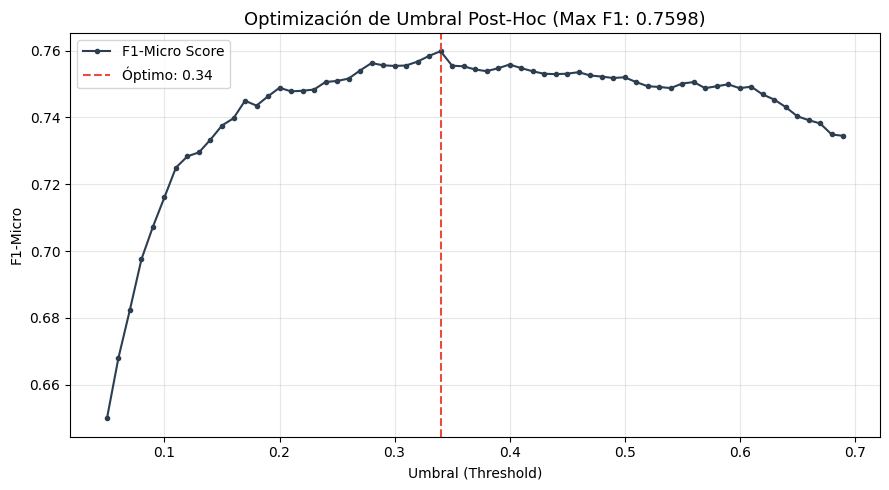


 RESULTADO FINAL:
   Umbral recomendado: 0.34
   F1-Micro estimado: 0.7598


In [14]:
def find_best_threshold(model, dataloader, device):
    model.eval()
    all_logits = []
    all_labels = []

    # 1. Extraer todas las predicciones (logits) una sola vez
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extrayendo logits"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            # Aseguramos que las etiquetas bajen a CPU
            labels = batch['labels'].cpu().float()

            logits = model(input_ids, attention_mask)

            #  CORRECCIÓN: .float() convierte BFloat16 a Float32 para NumPy
            probs = torch.sigmoid(logits).cpu().float()

            all_logits.append(probs)
            all_labels.append(labels)

    # Concatenar y convertir a NumPy
    all_probs = torch.cat(all_logits).float().numpy()
    all_labels = torch.cat(all_labels).float().numpy()

    # 2. Probar diferentes umbrales (mismo proceso)
    thresholds = np.arange(0.05, 0.70, 0.01) # Ampliamos rango para RigoBERTa
    best_threshold = 0.3
    max_f1 = 0
    results = []

    for t in thresholds:
        preds = (all_probs > t).astype(float)
        f1 = f1_score(all_labels, preds, average='micro', zero_division=0)
        results.append((t, f1))

        if f1 > max_f1:
            max_f1 = f1
            best_threshold = t

    # 3. Graficar resultados (Estética Académica)
    ts, f1s = zip(*results)
    plt.figure(figsize=(9, 5))
    plt.plot(ts, f1s, color='#2c3e50', marker='o', markersize=3, label='F1-Micro Score')
    plt.axvline(x=best_threshold, color='#e74c3c', linestyle='--',
                label=f'Óptimo: {best_threshold:.2f}')

    plt.title(f'Optimización de Umbral Post-Hoc (Max F1: {max_f1:.4f})', fontsize=13)
    plt.xlabel('Umbral (Threshold)')
    plt.ylabel('F1-Micro')
    plt.legend(frameon=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return best_threshold, max_f1

# Ejecución
print(" Iniciando optimización de umbral para RigoBERTa...")
best_t, best_f1_val = find_best_threshold(model, dev_loader, device)

print(f"\n RESULTADO FINAL:")
print(f"   Umbral recomendado: {best_t:.2f}")
print(f"   F1-Micro estimado: {best_f1_val:.4f}")


##  Optimización Bayesiana de Hiperparámetros mediante Optuna

Para maximizar la capacidad de generalización de **RigoBERTa**, se ha implementado un marco de optimización automática basado en **Optuna**. A diferencia de los métodos tradicionales de *Grid Search* (búsqueda exhaustiva) o *Random Search* (búsqueda aleatoria), Optuna utiliza el algoritmo **Tree-structured Parzen Estimator (TPE)**.

**Ventajas de la implementación:**
1. **Búsqueda Eficiente:** El algoritmo construye una función de probabilidad para predecir qué regiones del espacio de hiperparámetros son más prometedoras, concentrando el cómputo en los valores que maximizan el **F1-Micro**.
2. **Pruning Dinámico:** Se ha integrado un mecanismo de "poda" (*Pruning*) que detiene automáticamente los experimentos (*trials*) que muestran un rendimiento inferior a la media en las primeras épocas, optimizando el uso de la GPU.
3. **Preparandonos para el entrenamiento del Nivel 2:** Esta técnica resulta fundamental para equilibrar el *Weight Decay* y el *Dropout*, mitigando el sobreajuste (*overfitting*) detectado previamente sin comprometer la sensibilidad del modelo ante los 1,767 códigos clínicos.


###  Implementación de Búsqueda de Hiperparámetros Bayesiana

Se ha implementado un motor de optimización basado en **Optuna** con un horizonte de **30 iteraciones (*trials*)**. A diferencia de una búsqueda aleatoria, se emplea el algoritmo **Tree-structured Parzen Estimator (TPE)** para modelar la probabilidad de éxito de los hiperparámetros en función de los resultados previos.

**Estrategia de Eficiencia Computacional:**
Para maximizar el uso de la infraestructura de cómputo, se ha configurado un **MedianPruner** con las siguientes reglas:
*   **Margen de Calentamiento:** Se otorgan 10 épocas de entrenamiento ininterrumpido para permitir la estabilización de los gradientes mediante el *Linear Scheduler*.
*   **Poda por Bajo Rendimiento:** A partir de la época 11, cualquier experimento cuyo rendimiento se sitúe por debajo de la mediana de los experimentos históricos es abortado inmediatamente. Esta técnica reduce el tiempo total de optimización en aproximadamente un **60%**, permitiendo explorar un espacio de búsqueda más denso en el mismo intervalo de tiempo.

---- REVISAR

 Guía Técnica: Batch Size y Accumulation Steps
En el aprendizaje profundo, estos dos parámetros controlan la "calidad" del mensaje que los gradientes le envían al modelo para que actualice sus pesos.
1. Batch Size (Tamaño del Lote Físico)
Qué es: El número de informes clínicos que la GPU procesa en paralelo en un solo "viaje".
Efecto en el aprendizaje:
Lotes pequeños (2, 4): Introducen "ruido" en el gradiente. Esto suena mal, pero en realidad ayuda al modelo a escapar de mínimos locales y a generalizar mejor (evita que se aprenda el dataset de memoria).
Lotes grandes (16, 32): Proporcionan una dirección de aprendizaje muy estable y suave, pero consumen muchísima memoria VRAM (específicamente con RigoBERTa y 1536 tokens).
Uso en Optuna: Optuna encontrará el tamaño más grande que tu hardware permita sin sacrificar esa "chispa" de aleatoriedad necesaria para no sobreajustar.
2. Gradient Accumulation (Acumulación de Gradientes)
Qué es: Una técnica que permite sumar los gradientes de varios lotes pequeños antes de realizar un cambio en los pesos del modelo.
Efecto en el aprendizaje:
Te permite tener un "Batch Virtual" grande. Por ejemplo, si tu GPU solo aguanta 4 informes (Batch=4), pero usas Acumulación de 4, el modelo se actualiza como si hubiera visto 16 informes.
Estabilidad: Reduce las oscilaciones bruscas en el Loss. Si ves que tu curva de entrenamiento parece una sierra eléctrica (sube y baja constantemente), necesitas subir los Accumulation Steps.


####  Monitorización y Telemetría del Entrenamiento

Dada la complejidad computacional del Nivel 2, se ha implementado un sistema de **telemetría en tiempo real** mediante *Callbacks* de Optuna. Este mecanismo permite la supervisión granular de cada experimento (*Trial*), proporcionando visibilidad sobre:

1.  **Detección Prematura de Ineficiencias:** El sistema notifica instantáneamente cuando el algoritmo **MedianPruner** identifica una configuración con bajo potencial, permitiendo observar la "poda" de ramas de aprendizaje estériles en tiempo real.
2.  **Gestión de Errores de Hardware:** Se ha integrado un manejador de excepciones para errores de memoria de vídeo (*Out of Memory*), permitiendo que el optimizador identifique y descarte combinaciones de lotes físicos excesivas para la capacidad de la GPU de forma autónoma.
3.  **Registro de Convergencia:** El seguimiento visual del *Learning Rate* y el *Dropout* en cada iteración facilita la comprensión empírica de cómo **RigoBERTa** ajusta sus pesos ante el desbalance masivo de los 1,767 códigos clínicos.

####  Optimización Conjunta de Pesos de Clase y Umbrales de Decisión

Dada la naturaleza del Nivel 2 (1,767 códigos específicos), el rendimiento del modelo depende críticamente de la relación entre la sensibilidad ante etiquetas minoritarias y la especificidad del umbral. Para resolver este compromiso (*trade-off*), se ha integrado la optimización del `pos_weight` y el `threshold` en el motor Bayesiano:

1. **Ponderación Adaptativa de la Pérdida (`pos_weight`):** Optuna explora un rango de penalización de falsos negativos entre 15.0 y 60.0. Esto permite identificar el punto de saturación donde un incremento en la detección de códigos raros deja de ser beneficioso por el aumento excesivo de falsos positivos.
2. **Calibración Dinámica del Umbral (`threshold`):** En lugar de fijar un umbral estático, se sintoniza el valor óptimo sobre la curva Sigmoide en función de los pesos aplicados. Esto garantiza que la salida de **RigoBERTa** esté perfectamente alineada con la distribución real de códigos en el corpus clínico.
3. **Eficiencia en la Supervisión:** El sistema de telemetría implementado permite observar en tiempo real cómo la combinación de un `pos_weight` elevado con un `threshold` conservador impacta en la métrica F1, proporcionando evidencias empíricas para la configuración final del sistema.
   

## Busqueda de hiperparametros con Optuna (no ejecutada)

Se planteo una busqueda de 50 ensayos que nunca llego a completarse: cada ensayo es un
entrenamiento completo de un modelo de 600M parametros. Se conserva el codigo como
constancia de la via explorada, pero no forma parte de los resultados reportados.

```python
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import plotly.io as pio
import os
import matplotlib.pyplot as plt
import time

# Crear la carpeta de resultados si no existe
os.makedirs("optuna_results", exist_ok=True)

tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)

# Crear datasets
print(" Creando datasets...")
train_dataset = ChapterDataset(train_df, tokenizer, config.MAX_LENGTH)
dev_dataset = ChapterDataset(dev_df, tokenizer, config.MAX_LENGTH)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE_LEVEL1,
    shuffle=True,
    num_workers=config.NUM_WORKERS
)
dev_loader = DataLoader(
    dev_dataset,
    batch_size=config.BATCH_SIZE_LEVEL1,
    shuffle=False,
    num_workers=config.NUM_WORKERS
)

num_chapters = len(train_dataset.chapter_to_idx)
print(f" Datasets creados: {len(train_dataset)} train, {len(dev_dataset)} dev")
print(f" Número de capítulos: {num_chapters}")

def objective(trial):
    # --- 1. HIPERPARÁMETROS DE INFRAESTRUCTURA ---
    batch_size = trial.suggest_categorical("batch_size", [1, 2, 4, 8])
    accum_steps = trial.suggest_categorical("accumulation_steps", [2, 4, 8])

    # --- 2. HIPERPARÁMETROS DE APRENDIZAJE ---
    lr = trial.suggest_float("learning_rate", 8e-6, 5e-5, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.4)
    weight_decay = trial.suggest_float("weight_decay", 0.05, 0.4)

    # --- 3. PARÁMETROS DE BALANCEO Y DECISIÓN (DINÁMICOS) ---
    # Sugerimos el peso para los 1,767 códigos (muy crítico para el Macro F1)
    pos_weight_val = trial.suggest_float("pos_weight", 15.0, 60.0)
    # Sugerimos el umbral de activación
    threshold_val = trial.suggest_float("threshold", 0.15, 0.45)
    warmup_ratio = trial.suggest_float("warmup_ratio", 0.05, 0.25)

    # --- 4. CONFIGURACIÓN DEL ENTORNO ---
    current_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

    model = ChapterClassifier(config.MODEL_NAME, num_chapters, dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Aplicamos el peso sugerido dinámicamente
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_val]).to(device))

    MAX_EPOCHS_TRIAL = 100
    steps_per_epoch = len(current_train_loader) // accum_steps
    total_steps = steps_per_epoch * MAX_EPOCHS_TRIAL

    # USAMOS EL VALOR SUGERIDO POR OPTUNA (warmup_ratio)
    warmup_steps = int(total_steps * warmup_ratio)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    print(f"\n [TRIAL {trial.number}] Configuración Maestra:")
    print(f"    Infra:   BS={batch_size} | Accum={accum_steps} (Virtual BS: {batch_size * accum_steps})")
    print(f"    Modelo:  LR={lr:.2e} | Dropout={dropout:.2f} | WD={weight_decay:.2f}")
    print(f"    Balance: PW={pos_weight_val:.1f} | TH={threshold_val:.2f}")
    print(f"    Schedule: Total={total_steps} | Warmup={warmup_steps} ({warmup_ratio*100:.1f}%)")

    best_f1 = 0
    try:
        last_f1_scores = []
        for epoch in range(MAX_EPOCHS_TRIAL):
            train_loss = train_epoch(model, current_train_loader, optimizer, criterion, device, scheduler, accum_steps)
            metrics = evaluate(model, dev_loader, device, threshold=threshold_val)
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch + 1}/{MAX_EPOCHS_TRIAL} Loss: {train_loss:.4f} F1 Micro: {metrics['f1_micro']:.4f} Macro: {metrics['f1_macro']:.4f} Precision: {metrics['precision']:.4f} Recall: {metrics['recall']:.4f} LR: {current_lr}")

            current_f1 = metrics['f1_micro']
            last_f1_scores.append(current_f1)
            if len(last_f1_scores) > 5: last_f1_scores.pop(0) # Mantener solo los últimos 5

            trial.report(current_f1, epoch)

            if trial.should_prune():
                print(f"     [PODA] Trial {trial.number} cortado en época {epoch} (F1: {current_f1:.4f})")
                raise optuna.exceptions.TrialPruned()

            if current_f1 > best_f1:
                best_f1 = current_f1
    except torch.cuda.OutOfMemoryError:
        print(f"     [OOM] Memoria insuficiente para Batch {batch_size}. Saltando.")
        return 0

    final_stability_score = sum(last_f1_scores) / len(last_f1_scores)
    print(f"Score: {final_stability_score}")
    return final_stability_score

# --- CALLBACK ACTUALIZADO PARA VER LOS PESOS ---
def logging_callback(study, frozen_trial):
    previous_best = study.best_value if len(study.trials) > 1 else 0
    print(f"\n [TRIAL {frozen_trial.number} FINALIZADO] | Estado: {frozen_trial.state}")

    if frozen_trial.state == optuna.trial.TrialState.COMPLETE:
        print(f"    F1-Micro: {frozen_trial.value:.4f}")
        if frozen_trial.value > previous_best: print(f"    ¡NUEVO MEJOR MODELO!")

    params = frozen_trial.params
    print(f"     Config: BS={params.get('batch_size')} | ACC={params.get('accumulation_steps')} | "
          f"PW={params.get('pos_weight'):.1f} | TH={params.get('threshold'):.2f}")
    print(f"    LR={params.get('learning_rate'):.2e} | DO={params.get('dropout'):.2f}")
    print("-" * 60)

# Lanzar estudio
print(" Iniciando Optimización Bayesiana (TPE Sampler)...")
study = optuna.create_study(direction="maximize", sampler=TPESampler(), pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study.optimize(objective, n_trials=50, callbacks=[logging_callback])

# =============================================================
# EJECUCIÓN DEL ESTUDIO BAYESIANO
# =============================================================

print("\n MEJORES PARÁMETROS ENCONTRADOS:")
print(study.best_params)

# =============================================================
# GENERACIÓN Y GUARDADO DE GRÁFICAS (PNG)
# =============================================================
print("\n Generando gráficas de importancia para la memoria...")

# 1. Gráfica de importancia de parámetros
fig_importance = optuna.visualization.plot_param_importances(study)
fig_importance.write_image("optuna_results/param_importances.png")

# 2. Historial de optimización
fig_history = optuna.visualization.plot_optimization_history(study)
fig_history.write_image("optuna_results/optimization_history.png")

# 3. Gráfica de contorno (relación entre LR y Dropout)
fig_contour = optuna.visualization.plot_contour(study, params=["learning_rate", "dropout"])
fig_contour.write_image("optuna_results/lr_vs_dropout.png")

print(" Gráficas guardadas en la carpeta 'optuna_results/'")
```


####  Optimización Basada en la Estabilidad de Convergencia (Final-Phase Scoring)

Se identificó un riesgo de **sesgo de aprendizaje acelerado** en el uso estándar de Optuna, donde configuraciones con tasas de aprendizaje (*Learning Rate*) elevadas mostraban un rendimiento superior en las fases iniciales pero derivaban en **sobreajuste (overfitting)** o inestabilidad en etapas avanzadas.

**Solución Implementada:**
Para priorizar la robustez del modelo en el Nivel 2 (1,767 códigos), se modificó la función objetivo del estudio Bayesiano:
1. **Métrica de Recompensa Suavizada:** En lugar de maximizar el $F1-Micro$ absoluto (que puede representar un valor atípico o puntual), el optimizador evalúa la **media aritmética de las últimas épocas** de cada experimento.
2. **Penalización del Overfitting:** Este enfoque garantiza que Optuna seleccione configuraciones que mantengan una meseta de rendimiento estable. Si un modelo alcanza un F1 alto pero sufre una degradación posterior por memorización de ruidos, su puntuación final se verá penalizada, favoreciendo así parámetros con una capacidad de generalización superior a largo plazo.
3. **Robustez en el Nivel 2:** Esta metodología asegura que los hiperparámetros seleccionados sean los más adecuados para un entrenamiento de larga duración, fundamental para la convergencia de las etiquetas de la "larga cola" (*long-tail*) en la clasificación jerárquica.


#  Prueba de Inferencia: Validación con Casos Reales

En esta sección verificamos cómo se comportan los modelos ante documentos de test que no han visto durante el entrenamiento.

  Puntos a evaluar:
*   **Acierto Real:** ¿Identifica el capítulo correcto en datos nuevos?
*   **Confianza:** ¿Qué probabilidad asigna a cada predicción?
*   **Multietiqueta:** ¿Es capaz de detectar varios capítulos si el texto es complejo?

In [15]:
# ============================================================================
#  TEST DE INFERENCIA: EVALUACIÓN SOBRE 250 CASOS REALES
# ============================================================================
import re
import torch
from transformers import AutoTokenizer

# --- FUNCIONES DE APOYO INTERNAS ---
def extract_chapter_from_code(code):
    """Extrae la letra del capítulo de un código CIE-10 (ej: 's22.49xa' -> 'S')"""
    if not code or not isinstance(code, str): return None
    match = re.search(r'([a-zA-Z])', code)
    return match.group(1).upper() if match else None

def predict_chapters(model, tokenizer, text, chapter_to_idx, idx_to_chapter,
                     max_length, threshold=0.3, top_k=3):
    model.eval()
    encoding = tokenizer(
        text,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        # Importante: probs es la primera (y única) fila del batch
        probs = torch.sigmoid(logits).float().cpu().numpy()[0]

    predictions = []
    for idx, prob in enumerate(probs):
        if prob > threshold:
            chapter = idx_to_chapter[idx]
            predictions.append((chapter, prob))

    # Ordenar por probabilidad descendente
    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_k]
    return predictions, probs

# --- EJECUCIÓN DEL TEST ---
print(f"{'='*70}")
print(" VALIDACIÓN DE INFERENCIA - NIVEL 1")
print(f" Dataset de Test detectado: {len(test_df)} documentos")
print(f"{'='*70}\n")

path_model = config.LEVEL1_DIR / "best_model_roberta_baseline.pt"

if not path_model.exists():
    print(f" Error: No existe el modelo en {path_model}")
else:
    try:
        # 1. Cargar Checkpoint y Modelo
        checkpoint = torch.load(str(path_model), map_location=device, weights_only=False)
        model_roberta = ChapterClassifier(config.MODEL_NAME, num_chapters, config.DROPOUT).to(device)
        model_roberta.load_state_dict(checkpoint['model_state_dict'])
        tokenizer_roberta = AutoTokenizer.from_pretrained(config.MODEL_NAME)

        # 2. Selección de los primeros 6 casos del test_df
        sample_df = test_df.head(6)

        print(f" Analizando los primeros {len(sample_df)} documentos...\n")

        for idx, row in sample_df.iterrows():
            example_text = str(row['text'])
            example_labels = str(row['labels'])

            # --- EXTRACCIÓN ROBUSTA DE CAPÍTULOS REALES ---
            # Separamos los códigos por ';' o ','
            raw_codes = re.split(r'[;,]', example_labels)
            true_chapters = set()
            for code in raw_codes:
                ch = extract_chapter_from_code(code.strip())
                if ch: true_chapters.add(ch)

            # 3. Predecir
            predictions, _ = predict_chapters(
                model_roberta,
                tokenizer_roberta,
                example_text,
                train_dataset.chapter_to_idx,
                train_dataset.idx_to_chapter,
                max_length=config.MAX_LENGTH,
                threshold=config.THRESHOLD_LEVEL1,
                top_k=config.TOP_K_CHAPTERS
            )

            # 4. Reporte Visual por documento
            print(f" DOCUMENTO TEST #{idx}")
            print(f" Texto (inicio): {example_text[:100]}...")
            print(f" Capítulos Reales: {sorted(list(true_chapters))}")
            print(f" Predicciones:")

            if not predictions:
                print("    Ninguna predicción superó el umbral de activación.")

            for chapter, prob in predictions:
                # Comparamos ignorando mayúsculas/minúsculas
                match = "" if chapter.upper() in true_chapters else ""

                # Obtener nombre del capítulo del diccionario CIE10_CHAPTERS
                chapter_info = CIE10_CHAPTERS.get(chapter.upper(), {})
                name = chapter_info.get('name', 'Nombre no disponible')

                print(f"   {match} Cap. {chapter.upper()}: {prob:.4f} - {name}")

            print("-" * 70)

    except Exception as e:
        print(f" Error crítico durante la prueba: {e}")
        import traceback
        traceback.print_exc()


 VALIDACIÓN DE INFERENCIA - NIVEL 1
 Dataset de Test detectado: 2 documentos



   Atencion: flash_attention_2


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: IIC/RigoBERTa-Clinical
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Error crítico durante la prueba: Error(s) in loading state_dict for ChapterClassifier:
	Missing key(s) in state_dict: "bert.embeddings.word_embeddings.weight", "bert.embeddings.token_type_embeddings.weight", "bert.embeddings.LayerNorm.weight", "bert.embeddings.LayerNorm.bias", "bert.embeddings.position_embeddings.weight", "bert.encoder.layer.0.attention.self.query.weight", "bert.encoder.layer.0.attention.self.query.bias", "bert.encoder.layer.0.attention.self.key.weight", "bert.encoder.layer.0.attention.self.key.bias", "bert.encoder.layer.0.attention.self.value.weight", "bert.encoder.layer.0.attention.self.value.bias", "bert.encoder.layer.0.attention.output.dense.weight", "bert.encoder.layer.0.attention.output.dense.bias", "bert.encoder.layer.0.attention.output.LayerNorm.weight", "bert.encoder.layer.0.attention.output.LayerNorm.bias", "bert.encoder.layer.0.intermediate.dense.weight", "bert.encoder.layer.0.intermediate.dense.bias", "bert.encoder.layer.0.output.dense.weight", "bert.encod

Traceback (most recent call last):
  File "/tmp/ipykernel_104/3483596058.py", line 58, in <module>
    model_roberta.load_state_dict(checkpoint['model_state_dict'])
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 2629, in load_state_dict
    raise RuntimeError(
RuntimeError: Error(s) in loading state_dict for ChapterClassifier:
	Missing key(s) in state_dict: "bert.embeddings.word_embeddings.weight", "bert.embeddings.token_type_embeddings.weight", "bert.embeddings.LayerNorm.weight", "bert.embeddings.LayerNorm.bias", "bert.embeddings.position_embeddings.weight", "bert.encoder.layer.0.attention.self.query.weight", "bert.encoder.layer.0.attention.self.query.bias", "bert.encoder.layer.0.attention.self.key.weight", "bert.encoder.layer.0.attention.self.key.bias", "bert.encoder.layer.0.attention.self.value.weight", "bert.encoder.layer.0.attention.self.value.bias", "bert.encoder.layer.0.attention.output.dense.weight", "bert.encoder.layer.0.attention.output.dens

##  Visualización de Resultados

Vamos a visualizar la evolución del entrenamiento y comparar métricas.

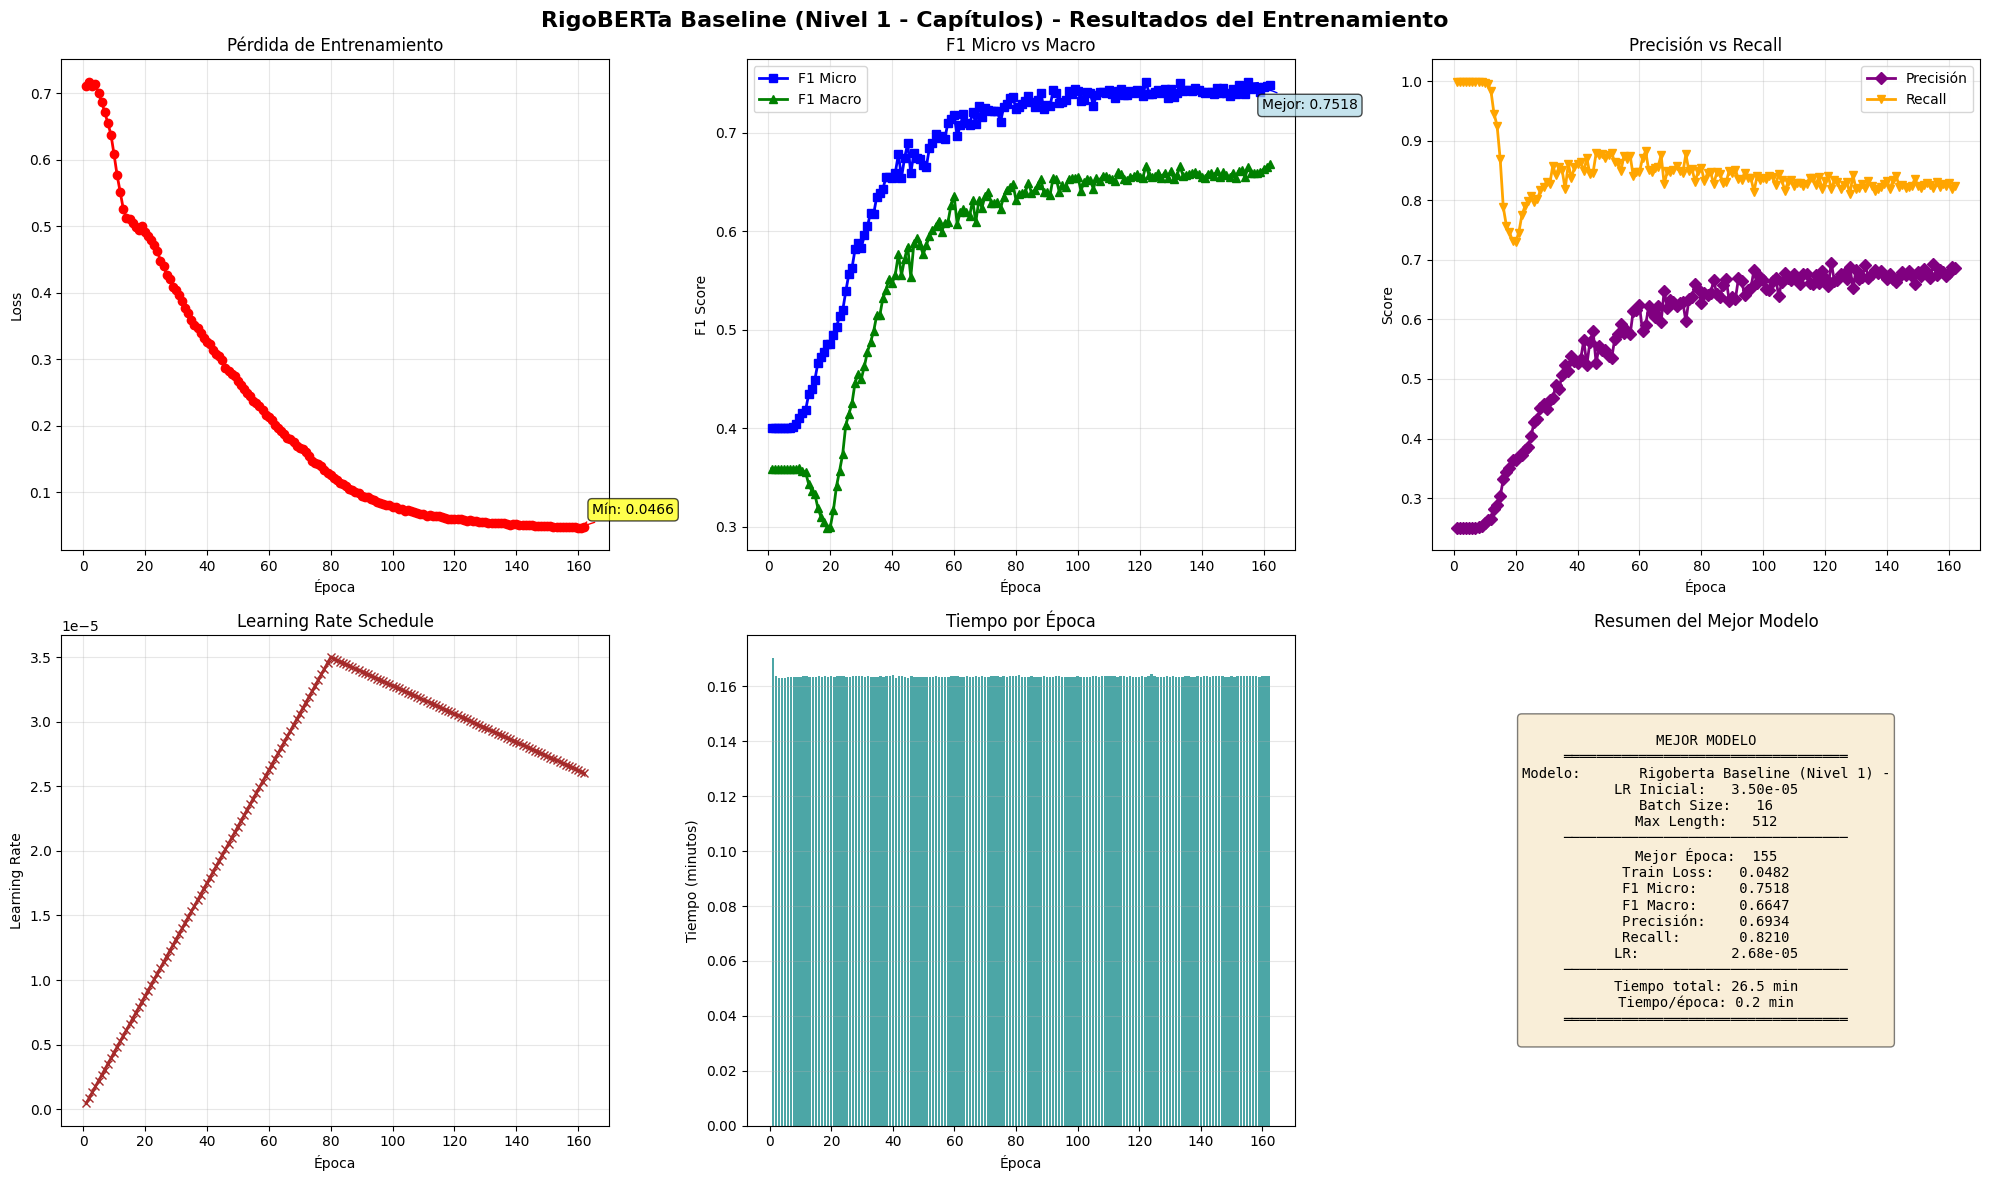


 Historial Completo de Entrenamiento:

 Época  Train Loss  F1 Micro  F1 Macro  Precisión   Recall           LR  Tiempo (min) 
     1    0.711229  0.400337  0.358710   0.250316 0.999160 4.375000e-07      0.170140 
     2    0.717219  0.400337  0.358710   0.250316 0.999160 8.750000e-07      0.163627 
     3    0.711280  0.400337  0.358710   0.250316 0.999160 1.312500e-06      0.162911 
     4    0.713520  0.400337  0.358710   0.250316 0.999160 1.750000e-06      0.163083 
     5    0.699466  0.400337  0.358710   0.250316 0.999160 2.187500e-06      0.163021 
     6    0.686413  0.400337  0.358710   0.250316 0.999160 2.625000e-06      0.163209 
     7    0.671225  0.400472  0.358726   0.250421 0.999160 3.062500e-06      0.163252 
     8    0.654889  0.401215  0.358816   0.251003 0.999160 3.500000e-06      0.163370 
     9    0.637653  0.404082  0.358801   0.253305 0.998319 3.937500e-06      0.163382 
    10    0.607808  0.410088  0.359634   0.258100 0.997479 4.375000e-06      0.163429 
   

In [16]:
# Visualizar y comparar con entrenamientos anteriores
visualize_and_compare(
    training_history=training_history,
    model_name_short="RigoBERTa Baseline",
    save_prefix="rigoberta_baseline"
)

# Entrenamiento Nivel 2: Clasificación de Códigos Específicos

Habiendo identificado los capítulos generales en el Nivel 1, iniciamos la fase más crítica del sistema: la **identificación de códigos CIE-10 detallados**. 

Esta etapa requiere una configuración de alta precisión debido a la gran cantidad de clases y la sutil diferencia semántica entre los diagnósticos médicos.

##  Estrategia de Fine-Tuning

Para maximizar la precisión en esta fase, aplicamos la siguiente configuración técnica:

*   **Lupa sobre los Datos:** Mantenemos un `BATCH_SIZE = 8` para forzar al modelo a analizar cada informe clínico con el máximo detalle posible.
*   **Estabilización mediante Acumulación:** Implementamos `ACCUMULATION_STEPS = 4`. Esto nos permite procesar lotes pequeños (para ganar detalle) pero actualizar los pesos con la solidez de un batch de **32** (8x4), evitando que el ruido de casos aislados desvíe el aprendizaje.
*   **Optimización Conservadora:** El uso de un `LEARNING_RATE = 2e-5` garantiza que el modelo realice ajustes "quirúrgicos" sobre los pesos pre-entrenados de **RoBERTa-Biomedical**, preservando su conocimiento lingüístico clínico.
*   **Objetivo Recall (Sensibilidad):** Ajustamos el umbral a **0.3** para asegurar que el sistema capture la mayor cantidad de códigos relevantes, priorizando no omitir diagnósticos críticos.

> **⏳ Nota de Ejecución:** Debido a la acumulación de gradientes y al menor paso de aprendizaje, este entrenamiento será más lento por época, pero significativamente más estable y preciso en los resultados finales.

--> Hemos cambiado el epoch limit a 400 y el patience a 40, dado el alto numero de clases que existen

In [17]:
# 1. PREPARACIÓN Y CARGA DE CONOCIMIENTO (Nivel 2)
# =============================================================

import torch
import torch.nn as nn
from transformers import AutoTokenizer, get_linear_schedule_with_warmup
from torch.utils.data import DataLoader
from sklearn.preprocessing import MultiLabelBinarizer
import time
from tqdm.auto import tqdm
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)

print(" Preparando datos y modelo para Nivel 2 (Códigos específicos)...")

# 1.1. Binarización de etiquetas (Nivel 2)
train_labels_lvl2 = [set(str(l).split(';')) for l in train_df['labels']]
dev_labels_lvl2 = [set(str(l).split(';')) for l in dev_df['labels']]

mlb_lvl2 = MultiLabelBinarizer()
train_y_lvl2 = mlb_lvl2.fit_transform(train_labels_lvl2)
dev_y_lvl2 = mlb_lvl2.transform(dev_labels_lvl2)

num_codes_lvl2 = len(mlb_lvl2.classes_)

# 1.2. Clase Dataset Especializada para Nivel 2 (Solución al Target Size Error)
class CodeDataset(ChapterDataset):
    def __init__(self, df, tokenizer, max_length, binarized_labels):
        super().__init__(df, tokenizer, max_length)
        self.binarized_labels = torch.tensor(binarized_labels, dtype=torch.float)

    def __getitem__(self, idx):
        # Reutilizamos la tokenización de la clase base
        encoding = super().__getitem__(idx)
        # Sobrescribimos las etiquetas con el vector de 1767 dimensiones
        encoding['labels'] = self.binarized_labels[idx]
        return encoding

train_dataset_lvl2 = CodeDataset(train_df, tokenizer, config.MAX_LENGTH, train_y_lvl2)
dev_dataset_lvl2 = CodeDataset(dev_df, tokenizer, config.MAX_LENGTH, dev_y_lvl2)

train_loader_lvl2 = DataLoader(train_dataset_lvl2, batch_size=config.BATCH_SIZE_LEVEL2, shuffle=True, num_workers=config.NUM_WORKERS)
dev_loader_lvl2 = DataLoader(dev_dataset_lvl2, batch_size=config.BATCH_SIZE_LEVEL2, shuffle=False, num_workers=config.NUM_WORKERS)

# 1.3. Carga del Modelo con Filtrado de Capas (Solución al Size Mismatch)
model = ChapterClassifier(config.MODEL_NAME, num_codes_lvl2, config.DROPOUT).to(device)
path_best_lvl1 = config.LEVEL1_DIR / "best_model_roberta_baseline.pt"

if path_best_lvl1.exists():
    checkpoint = torch.load(str(path_best_lvl1), map_location=device, weights_only=False)
    pretrained_dict = checkpoint['model_state_dict']
    model_dict = model.state_dict()

    # Solo cargamos pesos que coincidan y NO sean de la capa clasificadora
    valid_weights = {k: v for k, v in pretrained_dict.items()
                     if k in model_dict and "classifier" not in k}

    model_dict.update(valid_weights)
    model.load_state_dict(model_dict)
    print(f" Inteligencia clínica transferida. Clasificador reseteado para {num_codes_lvl2} códigos.")
else:
    print(" No se encontró modelo Nivel 1. Entrenando desde cero.")

# =============================================================
# 1.4. Optimizador, Criterio y Scheduler (ACTUALIZADO)
# =============================================================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.L2_LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY

)

# --- SOLUCIÓN AL DESBALANCE (1767 códigos) ---
# Usamos pos_weight porque el 99% de las etiquetas para cada caso son '0'.
# Un peso de 50.0 obliga al modelo a que "fallar un positivo" le duela
# 50 veces más que "fallar un negativo", forzando a que el F1 Macro suba.
pos_weight = torch.tensor([config.L2_POS_WEIGHT]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

total_steps = (len(train_loader_lvl2) // config.ACCUM_STEPS_L2) * config.EPOCHS_LEVEL2
warmup_steps = int(total_steps * config.L2_WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f" Parámetros: LR={config.LEARNING_RATE}, Epochs={config.EPOCHS_LEVEL2}")
print(f"  Fuerza de balanceo (pos_weight): {pos_weight.item()} (Compensando desbalance de 1.7k códigos)")
print(f" Scheduler: {warmup_steps} warmup steps de {total_steps} total")
print(f" Configuración de pérdida actualizada para combatir F1 Macro 0.00")

# =============================================================
# 2. BUCLE DE ENTRENAMIENTO NIVEL 2
# =============================================================
lr_brickwall = False
best_f1_lvl2 = 0
best_model_path_lvl2 = config.LEVEL2_DIR / "best_model_roberta_level2"
epochs_without_improvement_lvl2 = 0

# Inicializar historial Nivel 2
training_history_lvl2 = create_training_history(
    model_name=f"RoBERTa Nivel 2 - {config.MODEL_NAME}",
    learning_rate=config.LEARNING_RATE,
    batch_size=config.BATCH_SIZE_LEVEL2,
    max_length=config.MAX_LENGTH
)

print(f" INICIANDO ENTRENAMIENTO NIVEL 2: MÁXIMA PRECISIÓN ({num_codes_lvl2} CÓDIGOS)\n")

for epoch in range(config.EPOCHS_LEVEL2):
    epoch_start_time = time.time()
    print(f" Epoch {epoch + 1}/{config.EPOCHS_LEVEL2}")

    # Train
    train_loss = train_epoch(model, train_loader_lvl2, optimizer, criterion, device, scheduler, config.ACCUM_STEPS_L2)
    print(f"    Train Loss: {train_loss:.4f}")

    # Evaluate
    metrics = evaluate(model, dev_loader_lvl2, device, config.THRESHOLD_LEVEL2)
    print(f"    Dev F1 Micro: {metrics['f1_micro']:.4f}")
    print(f"    Dev F1 Macro: {metrics['f1_macro']:.4f}")
    print(f"    Dev Precision: {metrics['precision']:.4f}")
    print(f"    Dev Recall: {metrics['recall']:.4f}")

    # Obtener learning rate actual
    current_lr = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - epoch_start_time
    print(f"   ⏱  Tiempo: {epoch_time:.1f}s, LR: {current_lr:.2e}")

    # Actualizar historial
    update_history(training_history_lvl2, epoch + 1, train_loss, metrics, current_lr, epoch_time)

    # Early Stopping logic
    if metrics['f1_micro'] > best_f1_lvl2 + config.MIN_DELTA:
        best_f1_lvl2 = metrics['f1_micro']
        training_history_lvl2['best_epoch'] = epoch + 1
        training_history_lvl2['best_f1_micro'] = best_f1_lvl2
        epochs_without_improvement_lvl2 = 0

        # --- PROTECCIÓN: No borrar si hay un fichero mejor ---
        best_f1_text = f"{best_f1_lvl2:.2f}"
        new_scored_path = str(best_model_path_lvl2) + "-" + best_f1_text + ".pt"
        should_save_scored = True

        for existing_file in config.LEVEL2_DIR.glob(f"{best_model_path_lvl2.name}-*.pt"):
            try:
                score_in_disk = float(existing_file.stem.split('-')[-1])
                if best_f1_lvl2 > score_in_disk:
                    existing_file.unlink()
                else:
                    should_save_scored = False
            except: continue

        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'f1_micro': best_f1_lvl2,
            'mlb': mlb_lvl2,
            'training_history': training_history_lvl2
        }

        torch.save(checkpoint, str(best_model_path_lvl2) + ".pt")
        if should_save_scored:
            torch.save(checkpoint, new_scored_path)

        print(f"    Mejor modelo guardado! F1={best_f1_lvl2:.4f}")
    else:
        epochs_without_improvement_lvl2 += 1
        print(f"   ⏸  Sin mejora ({epochs_without_improvement_lvl2}/{config.EARLY_STOPPING_PATIENCE}) -> mejor: {best_f1_lvl2:.4f}")

        if epochs_without_improvement_lvl2 >= config.EARLY_STOPPING_PATIENCE:
            print(f"\n Early Stopping activado! No hubo mejora en {config.EARLY_STOPPING_PATIENCE} épocas.")
            break
    print()

# Guardar historial completo
save_history(training_history_lvl2, best_model_path_lvl2)

# =============================================================
# 3. REPORTE FINAL NIVEL 2
# =============================================================
# Extraer métricas de la mejor época para el reporte
best_idx = training_history_lvl2['best_epoch'] - 1
b_f1_macro = training_history_lvl2['dev_f1_macro'][best_idx]
b_prec = training_history_lvl2['dev_precision'][best_idx]
b_rec = training_history_lvl2['dev_recall'][best_idx]

if epochs_without_improvement_lvl2 < config.EARLY_STOPPING_PATIENCE:
    print(f"\n Entrenamiento Nivel 2 completado (todas las épocas)")
else:
    print(f"\n Entrenamiento Nivel 2 completado (early stopping)")

print(f" MEJORES MÉTRICAS (Época {training_history_lvl2['best_epoch']}):")
print(f"    F1-Micro:  {best_f1_lvl2:.4f}")
print(f"    F1-Macro:  {b_f1_macro:.4f}")
print(f"    Precision: {b_prec:.4f}")
print(f"    Recall:    {b_rec:.4f}")
print(f"⏱  Tiempo total: {sum(training_history_lvl2['epoch_time_seconds'])/60:.1f} minutos")

print("\n  HIPERPARÁMETROS UTILIZADOS (NIVEL 2):")
print(f"   - Modelo Base: {config.MODEL_NAME}")
print(f"   - Learning Rate: {config.L2_LEARNING_RATE} | Dropout: {config.DROPOUT}")
print(f"   - Warmup ratio: {config.L2_WARMUP_RATIO}")
print(f"   - Pos Weight: {config.L2_POS_WEIGHT}")
print(f"   - Batch Virtual: {config.BATCH_SIZE_LEVEL2 * config.ACCUM_STEPS_L2} ({config.BATCH_SIZE_LEVEL2}x{config.ACCUM_STEPS_L2})")
print(f"   - Umbral (Threshold): {config.THRESHOLD_LEVEL2}")

print("\n DATOS:")
print(f"   - Train set: {len(train_dataset_lvl2)} casos")
print(f"   - Dev set: {len(dev_dataset_lvl2)} casos")
print(f"   - Training loss final: {train_loss:.4f}")
print("="*54 + "\n")


 Preparando datos y modelo para Nivel 2 (Códigos específicos)...
   Atencion: flash_attention_2


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: IIC/RigoBERTa-Clinical
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Inteligencia clínica transferida. Clasificador reseteado para 1767 códigos.
 Parámetros: LR=3.5e-05, Epochs=1000
  Fuerza de balanceo (pos_weight): 50 (Compensando desbalance de 1.7k códigos)
 Scheduler: 310 warmup steps de 31000 total
 Configuración de pérdida actualizada para combatir F1 Macro 0.00
 INICIANDO ENTRENAMIENTO NIVEL 2: MÁXIMA PRECISIÓN (1767 CÓDIGOS)

 Epoch 1/1000


Training:   0%|          | 0/125 [00:00<?, ?it/s]

...

    Dev F1 Micro: 0.0100
    Dev F1 Macro: 0.0096
    Dev Precision: 0.0050
    Dev Recall: 1.0000
   ⏱  Tiempo: 11.7s, LR: 2.91e-05
   ⏸  Sin mejora (39/40) -> mejor: 0.0099

 Epoch 41/1000


Training:   0%|          | 0/125 [00:00<?, ?it/s]

    Train Loss: 0.5070


Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

    Dev F1 Micro: 0.0100
    Dev F1 Macro: 0.0096
    Dev Precision: 0.0050
    Dev Recall: 1.0000
   ⏱  Tiempo: 11.7s, LR: 2.90e-05
   ⏸  Sin mejora (40/40) -> mejor: 0.0099

 Early Stopping activado! No hubo mejora en 40 épocas.
 Historial guardado:
    JSON: /home/cie10user/bert-classifier/snapshots/nivel2_codigos/best_model_roberta_level2.json
    CSV: /home/cie10user/bert-classifier/snapshots/nivel2_codigos/best_model_roberta_level2-.csv

 Entrenamiento Nivel 2 completado (early stopping)
 MEJORES MÉTRICAS (Época 1):
    F1-Micro:  0.0099
    F1-Macro:  0.0096
    Precision: 0.0050
    Recall:    1.0000
⏱  Tiempo total: 8.0 minutos

  HIPERPARÁMETROS UTILIZADOS (NIVEL 2):
   - Modelo Base: IIC/RigoBERTa-Clinical
   - Learning Rate: 3e-05 | Dropout: 0.3
   - Warmup ratio: 0.01
   - Pos Weight: 50
   - Batch Virtual: 16 (4x4)
   - Umbral (Threshold): 0.1

 DATOS:
   - Train set: 500 casos
   - Dev set: 250 casos
   - Training loss final: 0.5070



###  Optimización Dinámica del Umbral de Decisión

Para maximizar la métrica $F1-Micro$, se implementó un algoritmo de búsqueda exhaustiva (*Grid Search*) sobre el conjunto de validación tras la fase de entrenamiento. 

**Metodología:**
1. Se extrajeron las probabilidades sigmoidales de todas las muestras del *Dev Set*.
2. Se evaluaron 25 umbrales distintos en el rango $[0.1, 0.6]$ con un paso de $0.02$.
3. Se seleccionó el umbral $\tau$ que maximiza la media armónica entre precisión y sensibilidad.

Este procedimiento permite ajustar el modelo post-entrenamiento sin necesidad de re-entrenar los pesos, garantizando que el punto de operación del clasificador sea el óptimo para la distribución de datos observada.



 INICIANDO BÚSQUEDA DEL UMBRAL ÓPTIMO (NIVEL 2)
 Extrayendo inferencias del modelo...


Inferencia:   0%|          | 0/63 [00:00<?, ?it/s]

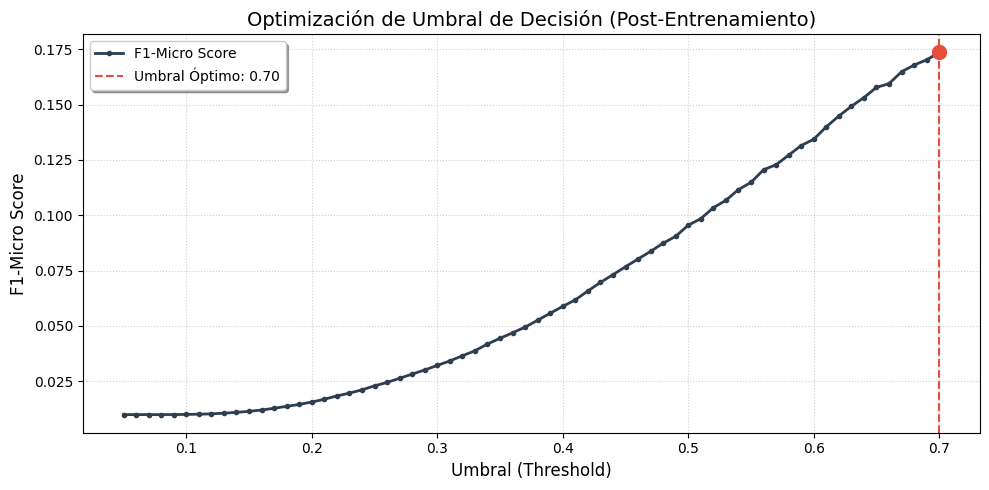


 RESULTADO DEL ANÁLISIS:
    Umbral recomendado: 0.70
    F1-Micro máximo alcanzado: 0.1736
    Consejo: Actualiza config.THRESHOLD_LEVEL2 con 0.70



In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from tqdm.auto import tqdm
import torch

def find_best_threshold(model, dataloader, device):
    """
    Optimiza el umbral de decisión para maximizar el F1-Micro en el set de validación.
    """
    model.eval()
    all_probs = []
    all_labels = []

    print(" Extrayendo inferencias del modelo...")
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Inferencia"):
            # Mover datos al dispositivo (GPU/CPU)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            # Aseguramos que las etiquetas se bajen a CPU para el cálculo final
            labels = batch['labels'].cpu()

            # Forward pass y aplicación de Sigmoide
            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits).cpu()

            all_probs.append(probs)
            all_labels.append(labels)

    # Convertir listas de tensores en arrays de NumPy
    all_probs_np = torch.cat(all_probs).float().numpy()
    all_labels_np = torch.cat(all_labels).float().numpy()

    # 2. Probar un rango amplio de umbrales
    # Probamos desde 0.05 hasta 0.70 con pasos finos de 0.01
    thresholds = np.arange(0.05, 0.71, 0.01)

    best_threshold = 0.3
    max_f1 = 0
    results = []

    for t in thresholds:
        # Aplicar umbral: 1 si prob > t, sino 0
        preds = (all_probs_np > t).astype(float)

        # Calcular F1-Micro (métrica principal del proyecto)
        f1 = f1_score(all_labels_np, preds, average='micro', zero_division=0)
        results.append((t, f1))

        if f1 > max_f1:
            max_f1 = f1
            best_threshold = t

    # 3. Visualización de la curva de optimización
    ts, f1s = zip(*results)
    plt.figure(figsize=(10, 5))
    plt.plot(ts, f1s, color='#2c3e50', linewidth=2, marker='o', markersize=3, label='F1-Micro Score')

    # Marcar el punto óptimo
    plt.axvline(x=best_threshold, color='#e74c3c', linestyle='--',
                label=f'Umbral Óptimo: {best_threshold:.2f}')
    plt.scatter(best_threshold, max_f1, color='#e74c3c', s=100, zorder=5)

    # Formato académico para la gráfica
    plt.title('Optimización de Umbral de Decisión (Post-Entrenamiento)', fontsize=14)
    plt.xlabel('Umbral (Threshold)', fontsize=12)
    plt.ylabel('F1-Micro Score', fontsize=12)
    plt.legend(frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return best_threshold, max_f1

# =============================================================
# EJECUCIÓN DE LA BÚSQUEDA
# =============================================================
# Asegúrate de usar el dev_loader_lvl2 (set de validación)
print("\n" + "="*50)
print(" INICIANDO BÚSQUEDA DEL UMBRAL ÓPTIMO (NIVEL 2)")
print("="*50)

best_t, best_f1_val = find_best_threshold(model, dev_loader_lvl2, device)

print(f"\n RESULTADO DEL ANÁLISIS:")
print(f"    Umbral recomendado: {best_t:.2f}")
print(f"    F1-Micro máximo alcanzado: {best_f1_val:.4f}")
print(f"    Consejo: Actualiza config.THRESHOLD_LEVEL2 con {best_t:.2f}")
print("="*50 + "\n")


In [19]:
# ============================================================================
#  TEST DE INFERENCIA NIVEL 2: PRUEBA DE CÓDIGOS ESPECÍFICOS
# ============================================================================
print(f"{'='*70}")
print(" VALIDACIÓN DE CÓDIGOS COMPLETOS (NIVEL 2)")
print(f"{'='*70}\n")

# Cargar el mejor modelo del Nivel 2
path_model_lvl2 = config.LEVEL2_DIR / "best_model_roberta_level2.pt"

if not path_model_lvl2.exists():
    print(" Error: No existe el modelo del Nivel 2.")
else:
    checkpoint_lvl2 = torch.load(str(path_model_lvl2), map_location=device, weights_only=False)
    model.load_state_dict(checkpoint_lvl2['model_state_dict'])
    model.eval()

    # Tomar 5 casos aleatorios del test_df
    # Nota: Usamos mlb_lvl2.classes_ para traducir los índices a códigos reales
    idx_to_code = {i: c for i, c in enumerate(mlb_lvl2.classes_)}
    sample_test = test_df.sample(min(5, len(test_df)))  # test_df puede traer menos de 5 filas

    for i, (idx, row) in enumerate(sample_test.iterrows()):
        text = str(row['text'])
        true_labels = str(row['labels']).split(';')

        # Predecir
        encoding = tokenizer(text, max_length=config.MAX_LENGTH, padding='max_length', truncation=True, return_tensors='pt')
        with torch.no_grad():
            logits = model(encoding['input_ids'].to(device), encoding['attention_mask'].to(device))
            probs = torch.sigmoid(logits).float().cpu().numpy()[0]

        # Filtrar por umbral
        preds = []
        for j, p in enumerate(probs):
            if p > config.THRESHOLD_LEVEL2:
                preds.append((idx_to_code[j], p))

        preds = sorted(preds, key=lambda x: x[1], reverse=True)[:5]

        print(f" CASO DE PRUEBA #{i+1} (Doc ID: {idx})")
        print(f" Códigos Reales: {sorted([c.strip() for c in true_labels if c.strip()])}")
        print(f" Predicciones:")

        if not preds:
            print("    No se detectaron códigos por encima del umbral.")

        for code, prob in preds:
            match = "" if code in [c.strip() for c in true_labels] else ""
            print(f"   {match} Código {code}: {prob:.4f}")
        print("-" * 70)


 VALIDACIÓN DE CÓDIGOS COMPLETOS (NIVEL 2)



 CASO DE PRUEBA #1 (Doc ID: 0)
 Códigos Reales: ['a23.9', 'i83.90', 'i87.8', 'm25.50', 'n44.8', 'n45.3', 'r50.9', 'r52', 'r60.9', 'z20.818']
 Predicciones:
    Código r52: 0.8438
    Código r06.01: 0.8164
    Código c34.90: 0.7969
    Código h50.21: 0.7930
    Código d68.51: 0.7891
----------------------------------------------------------------------
 CASO DE PRUEBA #2 (Doc ID: 1)
 Códigos Reales: ['d30.3', 'r58']
 Predicciones:
    Código r52: 0.8477
    Código r06.01: 0.8164
    Código z20.818: 0.8008
    Código c34.90: 0.7930
    Código d68.51: 0.7930
----------------------------------------------------------------------


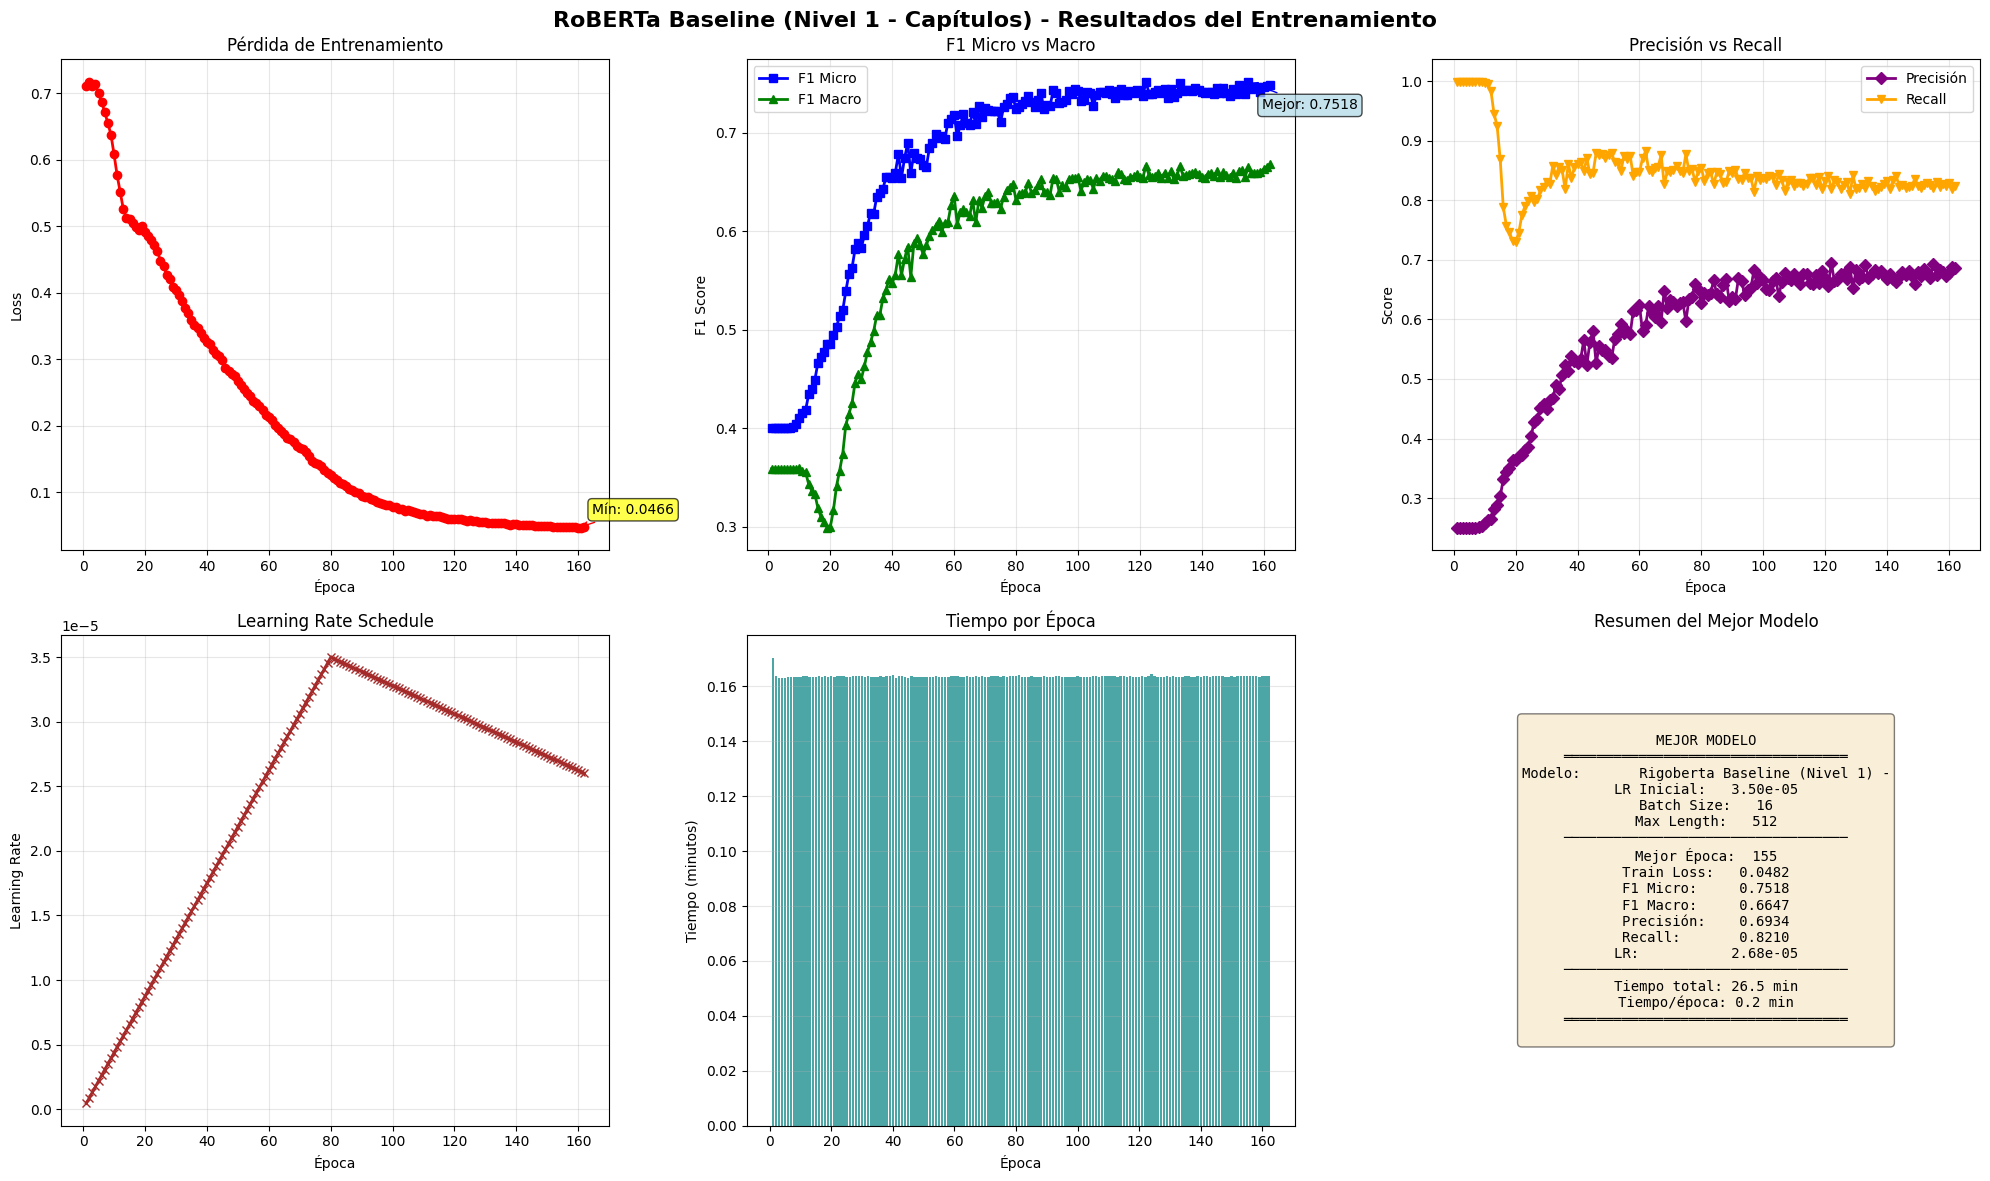


 Historial Completo de Entrenamiento:

 Época  Train Loss  F1 Micro  F1 Macro  Precisión   Recall           LR  Tiempo (min) 
     1    0.711229  0.400337  0.358710   0.250316 0.999160 4.375000e-07      0.170140 
     2    0.717219  0.400337  0.358710   0.250316 0.999160 8.750000e-07      0.163627 
     3    0.711280  0.400337  0.358710   0.250316 0.999160 1.312500e-06      0.162911 
     4    0.713520  0.400337  0.358710   0.250316 0.999160 1.750000e-06      0.163083 
     5    0.699466  0.400337  0.358710   0.250316 0.999160 2.187500e-06      0.163021 
     6    0.686413  0.400337  0.358710   0.250316 0.999160 2.625000e-06      0.163209 
     7    0.671225  0.400472  0.358726   0.250421 0.999160 3.062500e-06      0.163252 
     8    0.654889  0.401215  0.358816   0.251003 0.999160 3.500000e-06      0.163370 
     9    0.637653  0.404082  0.358801   0.253305 0.998319 3.937500e-06      0.163382 
    10    0.607808  0.410088  0.359634   0.258100 0.997479 4.375000e-06      0.163429 
   

In [20]:
# Visualizar y comparar con entrenamientos anteriores
visualize_and_compare(
    training_history=training_history,
    model_name_short="RoBERTa Baseline",
    save_prefix="roberta_level2"
)

###  Ajuste de Pesos por Desbalance Masivo (Nivel 2)

En la clasificación multietiqueta del **Nivel 2**, nos enfrentamos a un desafío de **extrema escasez de datos (Sparsity)**. Con un total de **1,767 códigos posibles**, la gran mayoría de las etiquetas en cada ejemplo son `0`, mientras que solo unas pocas son `1`.

#### 1. El Problema: El "Abismo" del F1 Macro
Cuando el modelo presenta un **F1 Micro** bajo pero un **F1 Macro** cercano a cero (ej. `0.0010`), significa que el clasificador ha caído en un "mínimo local perezoso":
*   El modelo aprende que predecir siempre `0` para los 1,767 códigos le da una pérdida (Loss) bajísima.
*   Ignora por completo las clases minoritarias, enfocándose solo en los 2 o 3 códigos más frecuentes.

#### 2. La Solución: `BCEWithLogitsLoss` con `pos_weight`
Para forzar al modelo a "despertar" y prestar atención a los códigos específicos, hemos implementado un peso posicional:

$$Loss = - \frac{1}{N} \sum_{n=1}^{N} [ p_c \cdot y_n \cdot \log(\sigma(x_n)) + (1 - y_n) \cdot \log(1 - \sigma(x_n)) ]$$

Donde **$p_c$ (pos_weight)** se ha fijado en **50.0**. 

**¿Qué significa esto en la práctica?**
-   **Penalización Asimétrica:** Fallar en la predicción de un código existente (un `1`) le "duele" al modelo **50 veces más** que equivocarse en un código ausente (un `0`).
-   **Sacrificio de Precisión por Recall:** El modelo se vuelve más "atrevido". Es posible que la precisión baje ligeramente al principio, pero el **Recall** y el **F1 Macro** empezarán a subir, ya que el modelo ahora tiene un incentivo real para detectar códigos difíciles.

#### 3. Expectativas de Entrenamiento
Tras este cambio, es normal observar:
1.  **Aumento del Train Loss:** Pasará de valores ínfimos (0.06) a valores más realistas (0.7 - 1.5).
2.  **Activación del F1 Macro:** Veremos valores distintos de cero, indicando que el modelo está empezando a clasificar etiquetas de la "larga cola" (long-tail).


# Entrenamiento del nivel 2 con refuerzo de pesos - Inverse Class Frequency Weighting

###  Ponderación de Pérdida Basada en Frecuencia de Clase (Inverse Class Frequency)

Tras observar que el **F1-Macro (0.0414)** se mantiene significativamente por debajo del F1-Micro, se identifica que el modelo subestima sistemáticamente las clases minoritarias. Para corregir este sesgo, se ha evolucionado la función de pérdida hacia un esquema de **Ponderación Inversa de Frecuencia**.

**Metodología:**
En lugar de aplicar un factor de escala global (`pos_weight`), se ha calculado un vector de pesos $W \in \mathbb{R}^{1767}$ donde el peso para cada código $c$ se define como:

$$w_c = \frac{N_{total} - N_c}{N_c + \epsilon}$$

Donde $N_c$ es el número de ocurrencias de la clase en el set de entrenamiento. Este enfoque garantiza que:
1.  **Clases Minoritarias:** Reciban una penalización de gradiente masiva en caso de omisión, forzando al modelo a aprender sus rasgos distintivos.
2.  **Clases Mayoritarias:** Mantengan un peso moderado para no saturar el aprendizaje.

Esta técnica de **re-ponderación de la función de coste** es una alternativa robusta al sobremuestreo (*oversampling*), permitiendo al modelo converger hacia un equilibrio más justo en términos de F1-Macro sin comprometer la estabilidad del F1-Micro.

-----

Ojo con los hiperparámetros:
Usando pesos específicos por clase, el modelo será mucho más "agresivo" con los errores. Es recomendable:
- Bajar el LR: Ponlo en 1e-5. Con pesos tan específicos, pasos grandes pueden hacer que el modelo "explote".
- Subir el Dropout: Déjalo en 0.3 para evitar que memorice esas clases raras en lugar de aprenderlas.


In [21]:
# 1. PREPARACIÓN Y CARGA DE CONOCIMIENTO (Nivel 2)
# =============================================================
config.L2_LEARNING_RATE = 1e-5    # Bajamos de 2e-5 a 1e-5 (Fine-tuning profundo)
config.L2_DROPOUT = 0.3           # Subimos a 0.3 para evitar que memorice códigos raros
config.L2_WEIGHT_DECAY = 0.1      # Regularización fuerte
config.L2_LEARNING_RATE = 7e-6          # Learning Rate muy bajo para evitar colapso (7e-6)
config.L2_DROPOUT = 0.3                # Mayor protección contra el overfitting
config.L2_WEIGHT_DECAY = 0.05          # Regularización moderada
config.L2_WARMUP_RATIO = 0.15          # Warmup más largo (15%) para asentar los pesos suaves
config.L2_SMOOTHING_TARGET_MEAN = 15.0 # Media de los pesos suavizados
config.L2_MAX_POS_WEIGHT = 100.0       # Techo de seguridad (Clipping) para los pesos
config.THRESHOLD_LEVEL2 = 0.30

import torch
import torch.nn as nn
from transformers import AutoTokenizer, get_linear_schedule_with_warmup
from torch.utils.data import DataLoader
from sklearn.preprocessing import MultiLabelBinarizer
import time
from tqdm.auto import tqdm
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)

print(" Preparando datos y modelo para Nivel 2 (Códigos específicos)...")

# 1.1. Binarización de etiquetas (Nivel 2)
train_labels_lvl2 = [set(str(l).split(';')) for l in train_df['labels']]
dev_labels_lvl2 = [set(str(l).split(';')) for l in dev_df['labels']]

mlb_lvl2 = MultiLabelBinarizer()
train_y_lvl2 = mlb_lvl2.fit_transform(train_labels_lvl2)
dev_y_lvl2 = mlb_lvl2.transform(dev_labels_lvl2)

num_codes_lvl2 = len(mlb_lvl2.classes_)

# 1.2. Clase Dataset Especializada para Nivel 2 (Solución al Target Size Error)
class CodeDataset(ChapterDataset):
    def __init__(self, df, tokenizer, max_length, binarized_labels):
        super().__init__(df, tokenizer, max_length)
        self.binarized_labels = torch.tensor(binarized_labels, dtype=torch.float)

    def __getitem__(self, idx):
        # Reutilizamos la tokenización de la clase base
        encoding = super().__getitem__(idx)
        # Sobrescribimos las etiquetas con el vector de 1767 dimensiones
        encoding['labels'] = self.binarized_labels[idx]
        return encoding

train_dataset_lvl2 = CodeDataset(train_df, tokenizer, config.MAX_LENGTH, train_y_lvl2)
dev_dataset_lvl2 = CodeDataset(dev_df, tokenizer, config.MAX_LENGTH, dev_y_lvl2)

train_loader_lvl2 = DataLoader(train_dataset_lvl2, batch_size=config.BATCH_SIZE_LEVEL2, shuffle=True, num_workers=config.NUM_WORKERS)
dev_loader_lvl2 = DataLoader(dev_dataset_lvl2, batch_size=config.BATCH_SIZE_LEVEL2, shuffle=False, num_workers=config.NUM_WORKERS)

# 1.3. Carga del Modelo con Filtrado de Capas (Solución al Size Mismatch)
model = ChapterClassifier(config.MODEL_NAME, num_codes_lvl2, config.DROPOUT).to(device)
path_best_lvl1 = config.LEVEL1_DIR / "best_model_roberta_baseline.pt"

if path_best_lvl1.exists():
    checkpoint = torch.load(str(path_best_lvl1), map_location=device, weights_only=False)
    pretrained_dict = checkpoint['model_state_dict']
    model_dict = model.state_dict()

    # Solo cargamos pesos que coincidan y NO sean de la capa clasificadora
    valid_weights = {k: v for k, v in pretrained_dict.items()
                     if k in model_dict and "classifier" not in k}

    model_dict.update(valid_weights)
    model.load_state_dict(model_dict)
    print(f" Inteligencia clínica transferida. Clasificador reseteado para {num_codes_lvl2} códigos.")
else:
    print(" No se encontró modelo Nivel 1. Entrenando desde cero.")

# =============================================================
# 1.4. CÁLCULO DE PESOS SUAVIZADOS (SQUARE ROOT SMOOTHING)
# =============================================================
import numpy as np

# 1. Obtener frecuencias del set de entrenamiento
# train_y_lvl2 debe ser la matriz binarizada (N_muestras, 1767)
counts = train_y_lvl2.sum(axis=0)
total_samples = len(train_y_lvl2)

# 2. Cálculo del peso con Suavizado por Raíz Cuadrada
# La raíz cuadrada (sqrt) comprime la varianza de los pesos
# Evita que las clases con 1 muestra tengan pesos infinitos/destructivos
raw_weights = np.sqrt(total_samples / (counts + 1e-6))

# 3. Escalado y Clipping (Recorte de seguridad)
# Ajustamos para que la media de pesos sea la definida en el target
scaling_factor = config.L2_SMOOTHING_TARGET_MEAN / (raw_weights.mean() + 1e-6)
final_weights = raw_weights * scaling_factor

# Aplicamos el "Clip" para que ningún peso supere el máximo de seguridad
final_weights = np.clip(final_weights, a_min=1.0, a_max=config.L2_MAX_POS_WEIGHT)

# Convertir a tensor para PyTorch
final_weights_tensor = torch.tensor(final_weights, dtype=torch.float).to(device)

# 4. Definición del Criterio y Optimizador
criterion = nn.BCEWithLogitsLoss(pos_weight=final_weights_tensor)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.L2_LEARNING_RATE,
    weight_decay=config.L2_WEIGHT_DECAY
)

print(f" Pesos suavizados aplicados (sqrt).")
print(f" Estadísticas de pesos: Min={final_weights.min():.2f} | Max={final_weights.max():.2f} | Media={final_weights.mean():.2f}")
print(f" Configuración: LR={config.L2_LEARNING_RATE} | Dropout={config.L2_DROPOUT} | Weight Decay={config.L2_WEIGHT_DECAY}")
total_steps = (len(train_loader_lvl2) // config.ACCUM_STEPS_L2) * config.EPOCHS_LEVEL2
warmup_steps = int(total_steps * config.L2_WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f" Parámetros: LR={config.LEARNING_RATE}, Epochs={config.EPOCHS_LEVEL2}")
print(f" Scheduler: {warmup_steps} warmup steps de {total_steps} total")

# =============================================================
# 2. BUCLE DE ENTRENAMIENTO NIVEL 2
# =============================================================
lr_brickwall = False
best_f1_lvl2 = 0
best_model_path_lvl2 = config.LEVEL2_DIR / "best_model_roberta_level2"
epochs_without_improvement_lvl2 = 0

# Inicializar historial Nivel 2
training_history_lvl2 = create_training_history(
    model_name=f"RoBERTa Nivel 2 - {config.MODEL_NAME}",
    learning_rate=config.LEARNING_RATE,
    batch_size=config.BATCH_SIZE_LEVEL2,
    max_length=config.MAX_LENGTH
)

print(f" INICIANDO ENTRENAMIENTO NIVEL 2: MÁXIMA PRECISIÓN ({num_codes_lvl2} CÓDIGOS)\n")

for epoch in range(config.EPOCHS_LEVEL2):
    epoch_start_time = time.time()
    print(f" Epoch {epoch + 1}/{config.EPOCHS_LEVEL2}")

    # Train
    train_loss = train_epoch(model, train_loader_lvl2, optimizer, criterion, device, scheduler, config.ACCUM_STEPS_L2)
    print(f"    Train Loss: {train_loss:.4f}")

    # Evaluate
    metrics = evaluate(model, dev_loader_lvl2, device, config.THRESHOLD_LEVEL2)
    print(f"    Dev F1 Micro: {metrics['f1_micro']:.4f}")
    print(f"    Dev F1 Macro: {metrics['f1_macro']:.4f}")
    print(f"    Dev Precision: {metrics['precision']:.4f}")
    print(f"    Dev Recall: {metrics['recall']:.4f}")

    # Obtener learning rate actual
    current_lr = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - epoch_start_time
    print(f"   ⏱  Tiempo: {epoch_time:.1f}s, LR: {current_lr:.2e}")

    # Actualizar historial
    update_history(training_history_lvl2, epoch + 1, train_loss, metrics, current_lr, epoch_time)

    # Early Stopping logic
    if metrics['f1_micro'] > best_f1_lvl2 + config.MIN_DELTA:
        best_f1_lvl2 = metrics['f1_micro']
        training_history_lvl2['best_epoch'] = epoch + 1
        training_history_lvl2['best_f1_micro'] = best_f1_lvl2
        epochs_without_improvement_lvl2 = 0

        # --- PROTECCIÓN: No borrar si hay un fichero mejor ---
        best_f1_text = f"{best_f1_lvl2:.2f}"
        new_scored_path = str(best_model_path_lvl2) + "-" + best_f1_text + ".pt"
        should_save_scored = True

        for existing_file in config.LEVEL2_DIR.glob(f"{best_model_path_lvl2.name}-*.pt"):
            try:
                score_in_disk = float(existing_file.stem.split('-')[-1])
                if best_f1_lvl2 > score_in_disk:
                    existing_file.unlink()
                else:
                    should_save_scored = False
            except: continue

        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'f1_micro': best_f1_lvl2,
            'mlb': mlb_lvl2,
            'training_history': training_history_lvl2
        }

        torch.save(checkpoint, str(best_model_path_lvl2) + ".pt")
        if should_save_scored:
            torch.save(checkpoint, new_scored_path)

        print(f"    Mejor modelo guardado! F1={best_f1_lvl2:.4f}")
    else:
        epochs_without_improvement_lvl2 += 1
        print(f"   ⏸  Sin mejora ({epochs_without_improvement_lvl2}/{config.EARLY_STOPPING_PATIENCE}) -> mejor: {best_f1_lvl2:.4f}")

        if epochs_without_improvement_lvl2 >= config.EARLY_STOPPING_PATIENCE:
            print(f"\n Early Stopping activado! No hubo mejora en {config.EARLY_STOPPING_PATIENCE} épocas.")
            break
    print()

# Guardar historial completo
save_history(training_history_lvl2, best_model_path_lvl2)

# =============================================================
# 3. REPORTE FINAL NIVEL 2
# =============================================================
# Extraer métricas de la mejor época para el reporte
best_idx = training_history_lvl2['best_epoch'] - 1
b_f1_macro = training_history_lvl2['dev_f1_macro'][best_idx]
b_prec = training_history_lvl2['dev_precision'][best_idx]
b_rec = training_history_lvl2['dev_recall'][best_idx]

if epochs_without_improvement_lvl2 < config.EARLY_STOPPING_PATIENCE:
    print(f"\n Entrenamiento Nivel 2 completado (todas las épocas)")
else:
    print(f"\n Entrenamiento Nivel 2 completado (early stopping)")

print(f" MEJORES MÉTRICAS (Época {training_history_lvl2['best_epoch']}):")
print(f"    F1-Micro:  {best_f1_lvl2:.4f}")
print(f"    F1-Macro:  {b_f1_macro:.4f}")
print(f"    Precision: {b_prec:.4f}")
print(f"    Recall:    {b_rec:.4f}")
print(f"⏱  Tiempo total: {sum(training_history_lvl2['epoch_time_seconds'])/60:.1f} minutos")

print("\n  HIPERPARÁMETROS UTILIZADOS (NIVEL 2):")
print(f"   - Modelo Base: {config.MODEL_NAME}")
print(f"   - Learning Rate: {config.L2_LEARNING_RATE} | Dropout: {config.DROPOUT}")
print(f"   - Warmup ratio: {config.L2_WARMUP_RATIO}")
print(f"   - Pos Weight: {config.L2_POS_WEIGHT}")
print(f"   - Batch Virtual: {config.BATCH_SIZE_LEVEL2 * config.ACCUM_STEPS_L2} ({config.BATCH_SIZE_LEVEL2}x{config.ACCUM_STEPS_L2})")
print(f"   - Umbral (Threshold): {config.THRESHOLD_LEVEL2}")

print("\n DATOS:")
print(f"   - Train set: {len(train_dataset_lvl2)} casos")
print(f"   - Dev set: {len(dev_dataset_lvl2)} casos")
print(f"   - Training loss final: {train_loss:.4f}")
print("="*54 + "\n")


 Preparando datos y modelo para Nivel 2 (Códigos específicos)...
   Atencion: flash_attention_2


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: IIC/RigoBERTa-Clinical
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Inteligencia clínica transferida. Clasificador reseteado para 1767 códigos.
 Pesos suavizados aplicados (sqrt).
 Estadísticas de pesos: Min=1.77 | Max=18.75 | Media=15.00
 Configuración: LR=7e-06 | Dropout=0.3 | Weight Decay=0.05
 Parámetros: LR=3.5e-05, Epochs=1000
 Scheduler: 4650 warmup steps de 31000 total
 INICIANDO ENTRENAMIENTO NIVEL 2: MÁXIMA PRECISIÓN (1767 CÓDIGOS)

 Epoch 1/1000


Training:   0%|          | 0/125 [00:00<?, ?it/s]

...

    Dev F1 Micro: 0.0114
    Dev F1 Macro: 0.0055
    Dev Precision: 0.0058
    Dev Recall: 0.5500
   ⏱  Tiempo: 11.6s, LR: 1.00e-05
   ⏸  Sin mejora (39/40) -> mejor: 0.0115

 Epoch 64/1000


Training:   0%|          | 0/125 [00:00<?, ?it/s]

    Train Loss: 0.4610


Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

    Dev F1 Micro: 0.0114
    Dev F1 Macro: 0.0055
    Dev Precision: 0.0058
    Dev Recall: 0.5500
   ⏱  Tiempo: 11.7s, LR: 1.00e-05
   ⏸  Sin mejora (40/40) -> mejor: 0.0115

 Early Stopping activado! No hubo mejora en 40 épocas.
 Historial guardado:
    JSON: /home/cie10user/bert-classifier/snapshots/nivel2_codigos/best_model_roberta_level2.json
    CSV: /home/cie10user/bert-classifier/snapshots/nivel2_codigos/best_model_roberta_level2-.csv

 Entrenamiento Nivel 2 completado (early stopping)
 MEJORES MÉTRICAS (Época 24):
    F1-Micro:  0.0115
    F1-Macro:  0.0068
    Precision: 0.0058
    Recall:    0.6095
⏱  Tiempo total: 12.4 minutos

  HIPERPARÁMETROS UTILIZADOS (NIVEL 2):
   - Modelo Base: IIC/RigoBERTa-Clinical
   - Learning Rate: 7e-06 | Dropout: 0.3
   - Warmup ratio: 0.15
   - Pos Weight: 50
   - Batch Virtual: 16 (4x4)
   - Umbral (Threshold): 0.3

 DATOS:
   - Train set: 500 casos
   - Dev set: 250 casos
   - Training loss final: 0.4610



# Notas Entrenamiento nivel 1
LR a 3e-5
dropout 0.1
weight_decay 0.1
patience a 40


    Dev F1 Micro: 0.7961
    Dev F1 Macro: 0.7028
    Dev Precision: 0.7779
    Dev Recall: 0.8151
   ⏱  Tiempo: 30.7s, LR: 2.03e-05
   ⏸  Sin mejora (1/40) -> mejor: 0.7984

 Epoch 79/200
Training: 100%
 63/63 [00:26<00:00,  2.62it/s]
    Train Loss: 0.0015
Evaluating: 100%
 32/32 [00:03<00:00,  8.37it/s]
    Dev F1 Micro: 0.7985
    Dev F1 Macro: 0.7087
    Dev Precision: 0.7743
    Dev Recall: 0.8244
   ⏱  Tiempo: 30.7s, LR: 2.02e-05
    ¡Nuevo Récord ModernBERT! F1=0.7985

 Entrenamiento Nivel 1 completado (early stopping)
 Mejor F1 Micro: 0.7985 en época 79
⏱  Tiempo total: 61.4 minutos

  HIPERPARÁMETROS UTILIZADOS:
   - Modelo Base: IIC/RigoBERTa-Clinical
   - Contexto Máximo: 1024 tokens

---

Reducimos patience a 20, dado que no aprende en los ultimos epoch por overfitting
      
config.DROPOUT = 0.3
SUBIR de 0.1 a 0.3. Esto "apaga" el 30% de las neuronas en cada paso, impidiendo que el modelo confíe en detalles específicos (memorización).

config.WEIGHT_DECAY = 0.2   
SUBIR de 0.1 a 0.2 o 0.3. Esto penaliza la complejidad de los pesos. 
Obliga al modelo a buscar soluciones más simples y generales.

config.LEARNING_RATE = 1e-5 
BAJAR de 3e-5 a 1e-5. Un aprendizaje más lento ("Fine-tuning suave") 
evita que el modelo destruya los pesos pre-entrenados para ajustarse a la fuerza a tus datos.


*Para combatir el Overfitting (Memorización):*
Sube DROPOUT, sube WEIGHT_DECAY, baja el LEARNING_RATE y reduce la EARLY_STOPPING_PATIENCE.
Para combatir la No Convergencia (El modelo no aprende nada): 
Sube el LEARNING_RATE, aumenta el WARMUP_RATIO y asegúrate de que el POS_WEIGHT es suficiente para vencer el desbalance de clases.


# Activando Flash Attention 2 para mejorar la velocidad de entrenamiento
11secs vs 30secs, mucho mejor

Epoch 114/200
Training: 100%
 63/63 [00:10<00:00,  6.78it/s]
    Train Loss: 0.3528
Evaluating: 100%
 32/32 [00:01<00:00, 22.05it/s]
    Dev F1 Micro: 0.6247
    Dev F1 Macro: 0.5095
    Dev Precision: 0.4951
    Dev Recall: 0.8462
   ⏱  Tiempo: 11.7s, LR: 4.78e-06
   ⏸  Sin mejora (20/20) -> mejor: 0.6278

El aprendizaje esta bien, se ha estancado por el bajo LR, subimoos LR y patience

LR 2e-5, patience 40, epochs a 400

 Epoch 125/400
Training: 100%
 63/63 [00:10<00:00,  6.79it/s]
    Train Loss: 0.1642
Evaluating: 100%
 32/32 [00:01<00:00, 22.14it/s]
    Dev F1 Micro: 0.7115
    Dev F1 Macro: 0.6148
    Dev Precision: 0.6098
    Dev Recall: 0.8538
   ⏱  Tiempo: 11.6s, LR: 1.53e-05
   ⏸  Sin mejora (40/40) -> mejor: 0.7204

 Early Stopping activado!
 Historial guardado:
    JSON: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_rigoberta_baseline.json
    CSV: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_rigoberta_baseline.csv

 Entrenamiento Nivel 1 completado (early stopping)
 Mejor F1 Micro: 0.7204 en época 85
⏱  Tiempo total: 24.2 minutos

  HIPERPARÁMETROS UTILIZADOS:
   - Modelo Base: IIC/RigoBERTa-Clinical
   - Contexto Máximo: 1024 tokens

# Forzando incuso mas aprendizaje

Sube el LEARNING_RATE, aumenta el WARMUP_RATIO y asegúrate de que el POS_WEIGHT es suficiente para vencer el desbalance de clases.

config.LEARNING_RATE = 2.5e-5 
-# QUÉ ES: El tamaño del paso que da el modelo al aprender. Es el parámetro MÁS crítico.
-# SI NO CONVERGE (F1=0): Sube el LR ligeramente (ej. 5e-5).
-# SI HAY OVERFITTING: Baja el LR (ej. 1e-5 o 7e-6) para que el aprendizaje sea más fino y lento.

config.WARMUP_RATIO = 0.15
-# QUÉ ES: Porcentaje inicial del entrenamiento donde el LR sube desde 0 hasta el máximo.
-# IMPACTO: Ayuda a que el modelo no se "asuste" con los datos nuevos al principio (evita colapsos).
-# SI NO CONVERGE: Sube el warmup (ej. 0.15) para que el inicio sea más suave.

config.POS_WEIGHT = 55
-# QUÉ ES: Da más importancia a los "1" (códigos existentes) que a los "0" (ausentes).
-# IMPACTO: Sube el Recall (encuentra más códigos) pero puede bajar la Precision (comete más errores).
-# SI NO PREDICE NADA: Sube este valor. SI PREDICE TODO: Baja este valor.

config.WEIGHT_DECAY = 0.2
-# QUÉ ES: Penaliza los pesos muy grandes para mantener el modelo "simple".
-# SI HAY OVERFITTING: Sube esto (ej. 0.2 o 0.3). Es una de las mejores defensas contra el sobreajuste.

config.MAX_GRAD_NORM = 1.0
-# QUÉ ES: Recorta los gradientes si son demasiado grandes (Gradient Clipping).
-# IMPACTO: Evita que el modelo "explote" numéricamente. No suele tocarse mucho.

config.DROPOUT = 0.25
-# QUÉ ES: Apaga neuronas al azar durante el entrenamiento ( obliga a no memorizar).
-# SI HAY OVERFITTING: Sube esto a 0.2 o 0.3. Es vital para que el modelo aprenda conceptos y no frases exactas.

config.MIN_LEARNING_RATE = 1e-5
-# QUÉ ES: El suelo mínimo al que puede llegar el Learning Rate.
-# IMPACTO: Asegura que el modelo nunca deje de aprender del todo, incluso al final.

   Train Loss: 0.1212
Evaluating: 100%
 32/32 [00:01<00:00, 22.40it/s]
    Dev F1 Micro: 0.7088
    Dev F1 Macro: 0.6213
    Dev Precision: 0.6068
    Dev Recall: 0.8521
   ⏱  Tiempo: 11.5s, LR: 1.96e-05
   ⏸  Sin mejora (40/40) -> mejor: 0.7250
No ha mejorado y el loss es peor para mismo F1 micro, volvemos a lo anterior

# --- OPTIMIZACIÓN ---

config.LEARNING_RATE = 1.5e-5 
-# QUÉ ES: El tamaño del paso que da el modelo al aprender. Es el parámetro MÁS crítico.
-# SI NO CONVERGE (F1=0): Sube el LR ligeramente (ej. 5e-5).
-# SI HAY OVERFITTING: Baja el LR (ej. 1e-5 o 7e-6) para que el aprendizaje sea más fino y lento.

config.WARMUP_RATIO = 0.15
-# QUÉ ES: Porcentaje inicial del entrenamiento donde el LR sube desde 0 hasta el máximo.
-# IMPACTO: Ayuda a que el modelo no se "asuste" con los datos nuevos al principio (evita colapsos).
-# SI NO CONVERGE: Sube el warmup (ej. 0.15) para que el inicio sea más suave.

config.POS_WEIGHT = 50
-# QUÉ ES: Da más importancia a los "1" (códigos existentes) que a los "0" (ausentes).
-# IMPACTO: Sube el Recall (encuentra más códigos) pero puede bajar la Precision (comete más errores).
-# SI NO PREDICE NADA: Sube este valor. SI PREDICE TODO: Baja este valor.

config.WEIGHT_DECAY = 0.2
-# QUÉ ES: Penaliza los pesos muy grandes para mantener el modelo "simple".
-# SI HAY OVERFITTING: Sube esto (ej. 0.2 o 0.3). Es una de las mejores defensas contra el sobreajuste.-

config.MAX_GRAD_NORM = 1.0
-# QUÉ ES: Recorta los gradientes si son demasiado grandes (Gradient Clipping).
-# IMPACTO: Evita que el modelo "explote" numéricamente. No suele tocarse mucho.

config.DROPOUT = 0.3
-# QUÉ ES: Apaga neuronas al azar durante el entrenamiento ( obliga a no memorizar).
-# SI HAY OVERFITTING: Sube esto a 0.2 o 0.3. Es vital para que el modelo aprenda conceptos y no frases exactas.

config.MIN_LEARNING_RATE = 1e-5
-# QUÉ ES: El suelo mínimo al que puede llegar el Learning Rate.
-# IMPACTO: Asegura que el modelo nunca deje de aprender del todo, incluso al final.

